# VFX Movies Deep-Dive: MCU, DC, and Superhero Universe Analytics
**Dataset:** TMDB_all_movies.csv  
**Scope:** Full VFX pipeline — MCU / DC isolation — Actor analytics — Director-Actor combinations — Superhero Reach and Power Index  
**Stack:** DuckDB, Pandas, Matplotlib, Seaborn, Neo4j

In this notebook, I conduct a comprehensive analytical exploration of VFX-heavy films with a focus on the Marvel Cinematic Universe (MCU) and DC Extended Universe (DC). I apply structured query processing via DuckDB, actor-level disaggregation, composite scoring models, and graph-ready data exports to derive insights on performance, talent, and franchise cultural reach.

---

In [60]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, textwrap

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#0d1117",
    "axes.edgecolor":   "#30363d",
    "text.color":       "#e6edf3",
    "axes.labelcolor":  "#e6edf3",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "axes.titlecolor":  "#e6edf3",
    "grid.color":       "#21262d",
    "figure.dpi":       130,
})

MCU_COLOR = "#e23636"   # Marvel red
DC_COLOR  = "#0476D0"   # DC blue
VFX_COLOR = "#f0c030"   # gold

FILE_PATH = "TMDB_all_movies.csv"
conn = duckdb.connect()
print("Imports & config ready")


Imports & config ready


## Load Raw Data and Build Clean Table

I begin by ingesting the raw CSV into DuckDB and constructing a cleaned table. This step applies type casting, null handling, and ROI derivation, ensuring all downstream queries operate on validated, consistent records.

In [61]:
conn.sql(f"""
    CREATE OR REPLACE TABLE raw_movies AS
    SELECT * FROM read_csv_auto('{FILE_PATH}',
        nullstr=['', 'NA', 'N/A'],
        header=true
    )
""")

conn.sql("""
    CREATE OR REPLACE TABLE clean_movies AS
    SELECT
        id,
        title,
        original_title,
        TRIM(director)                                       AS director,
        TRY_CAST(release_date AS DATE)                       AS release_date,
        YEAR(TRY_CAST(release_date AS DATE))                 AS release_year,
        genres,
        overview,
        tagline,
        original_language,
        production_companies,
        production_countries,
        "cast"                                              AS cast_list,
        writers,
        producers,
        music_composer,
        director_of_photography,
        popularity,
        NULLIF(budget,  0)                                   AS budget,
        NULLIF(revenue, 0)                                   AS revenue,
        CASE
            WHEN budget > 0 AND revenue > 0
            THEN ROUND((revenue - budget) / budget * 100, 2)
        END                                                  AS roi_pct,
        runtime,
        ROUND(imdb_rating, 1)                                AS rating,
        NULLIF(imdb_votes, 0)                                AS vote_count,
        vote_average,
        status,
        poster_path
    FROM raw_movies
    WHERE title    IS NOT NULL
      AND status   = 'Released'
      AND director IS NOT NULL
      AND TRIM(director) != ''
""")

total = conn.sql("SELECT COUNT(*) AS n FROM clean_movies").fetchone()[0]
print(f"clean_movies → {total:,} rows")


clean_movies → 975,454 rows


## Filter VFX Movies

I isolate VFX-relevant films by filtering on genre tags (Action, Science Fiction, Fantasy, Adventure, Animation) and keyword signals in the `overview` and `tagline` fields. This broad but deliberate filter establishes the analytical universe before narrowing to MCU and DC subsets.

In [62]:
conn.sql("""
    CREATE OR REPLACE TABLE vfx_movies AS
    SELECT *
    FROM clean_movies
    WHERE (
        LOWER(genres)   LIKE '%science fiction%'
        OR LOWER(genres)   LIKE '%action%'
        OR LOWER(genres)   LIKE '%fantasy%'
        OR LOWER(genres)   LIKE '%adventure%'
        OR LOWER(genres)   LIKE '%animation%'
        OR LOWER(overview) LIKE '%visual effects%'
        OR LOWER(overview) LIKE '%cgi%'
        OR LOWER(overview) LIKE '%special effects%'
        OR LOWER(tagline)  LIKE '%visual effects%'
        OR LOWER(tagline)  LIKE '%cgi%'
    )
""")

n_vfx = conn.sql("SELECT COUNT(*) FROM vfx_movies").fetchone()[0]
print(f"vfx_movies → {n_vfx:,} movies")
#to export the filtered dataset to a CSV file, you can uncomment the following lines:
#conn.sql("COPY vfx_movies TO 'vfx_movies_check.csv' (HEADER, DELIMITER ',')")
#print("Saved → vfx_movies_check.csv") 


vfx_movies → 155,131 movies


## MCU and DC Universe Isolation

I tag movies at the universe level by matching title strings, production company names, and cast signals against curated MCU and DC keyword lists. This logic provides clean universe-level segmentation without reliance on an external classification column.

In [63]:
# ── MCU keyword signals ────────────────────────────────────────────────────
MCU_TITLES = [
    'Iron Man','Thor','Captain America','The Avengers','Avengers',
    'Guardians of the Galaxy','Ant-Man','Black Panther','Doctor Strange',
    'Spider-Man','Black Widow','Shang-Chi','Eternals','Hawkeye',
    'WandaVision','Loki','Falcon','Scarlet Witch','Captain Marvel',
    'Infinity War','Endgame','Age of Ultron','Civil War','Winter Soldier',
    'Wakanda Forever','Quantumania','Multiverse of Madness','No Way Home',
    'Love and Thunder','She-Hulk','Moon Knight','Ms. Marvel','Secret Invasion',
    'The Marvels','Deadpool','Wolverine'
]

DC_TITLES = [
    'Superman','Batman','Wonder Woman','Justice League','Aquaman',
    'Shazam','The Flash','Green Lantern','Joker','Birds of Prey',
    'Harley Quinn','Suicide Squad','Black Adam','Cyborg',
    'Man of Steel','Batman v Superman','Dawn of Justice',
    'The Dark Knight','Batman Begins','Watchmen','V for Vendetta',
    'Constantine','Swamp Thing','Green Arrow','Batgirl','Blue Beetle',
    'Black Canary'
]

def build_title_filter(titles, col="title"):
    return " OR ".join([f"LOWER({col}) LIKE '%{t.lower()}%'" for t in titles])

mcu_filter = f"({build_title_filter(MCU_TITLES)}) OR LOWER(production_companies) LIKE '%marvel%'"
dc_filter  = (f"({build_title_filter(DC_TITLES)}) OR LOWER(production_companies) LIKE '%dc%' "
               "OR LOWER(production_companies) LIKE '%warner%'")

conn.sql(f"""
    CREATE OR REPLACE TABLE mcu_movies AS
    SELECT *, 'MCU' AS universe
    FROM vfx_movies
    WHERE {mcu_filter}
""")

conn.sql(f"""
    CREATE OR REPLACE TABLE dc_movies AS
    SELECT *, 'DC' AS universe
    FROM vfx_movies
    WHERE {dc_filter}
""")

conn.sql("""
    CREATE OR REPLACE TABLE universe_movies AS
    SELECT * FROM mcu_movies
    UNION ALL
    SELECT * FROM dc_movies
""")

n_mcu = conn.sql("SELECT COUNT(*) FROM mcu_movies").fetchone()[0]
n_dc  = conn.sql("SELECT COUNT(*) FROM dc_movies").fetchone()[0]
print(f"MCU movies: {n_mcu}")
print(f"DC  movies: {n_dc}")


MCU movies: 370
DC  movies: 2408


## Universe Overview — Rating, Revenue, and ROI

I produce a side-by-side comparison of the two universes across three primary performance dimensions: average IMDb rating, average box-office revenue, and average return on investment.

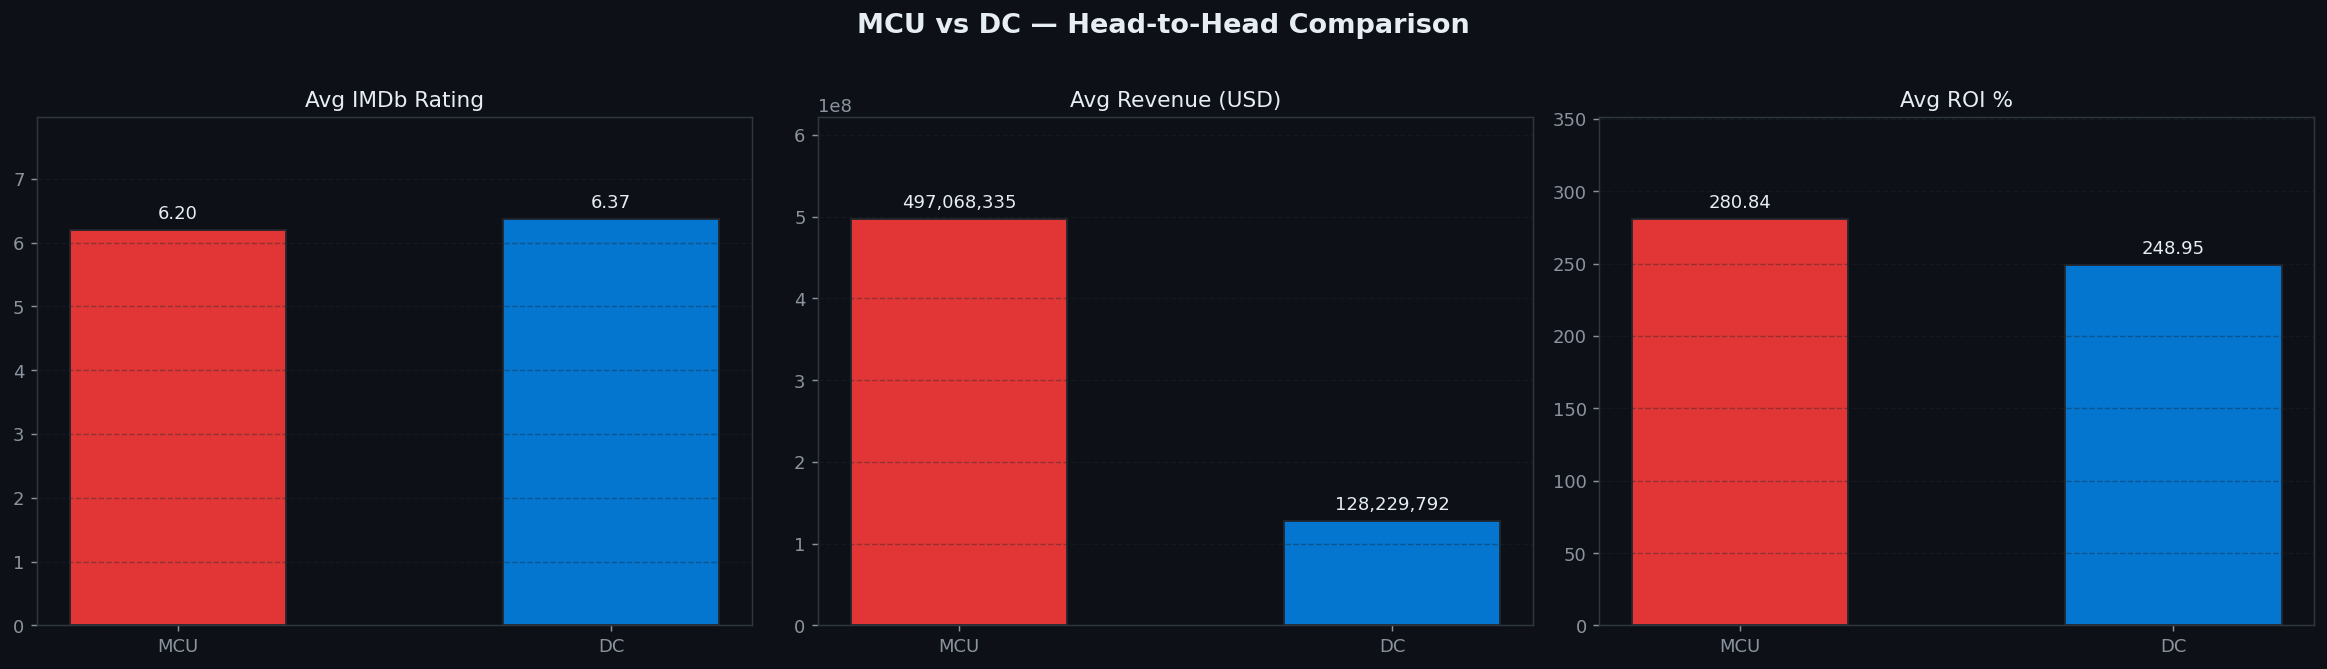

In [64]:
df_mcu = conn.sql("SELECT title, release_year, rating, revenue, roi_pct, vote_count, director, cast_list FROM mcu_movies ORDER BY release_year").df()
df_dc  = conn.sql("SELECT title, release_year, rating, revenue, roi_pct, vote_count, director, cast_list FROM dc_movies  ORDER BY release_year").df()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MCU vs DC — Head-to-Head Comparison", fontsize=15, fontweight="bold", color="#e6edf3", y=1.02)

metrics = [("rating", "Avg IMDb Rating"), ("revenue", "Avg Revenue (USD)"), ("roi_pct", "Avg ROI %")]
for ax, (col, label) in zip(axes, metrics):
    mcu_val = df_mcu[col].dropna().mean()
    dc_val  = df_dc[col].dropna().mean()
    bars = ax.bar(["MCU", "DC"], [mcu_val, dc_val], color=[MCU_COLOR, DC_COLOR], width=0.5, edgecolor="#21262d")
    ax.set_title(label, fontsize=12)
    ax.bar_label(bars, fmt=lambda x: (f"{x:,.0f}" if x > 1000 else f"{x:.2f}") if x == x else "N/A", padding=4, color="#e6edf3", fontsize=10)
    ax.set_ylim(0, max(v for v in [mcu_val, dc_val] if v == v) * 1.25)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()
# Result interpretation: This chart reveals whether MCU or DC leads on each
# dimension. A higher average rating indicates stronger critical reception;
# higher revenue reflects commercial dominance; higher ROI indicates more
# efficient capital deployment relative to production budgets.


## Actor-Level Analytics

I explode the `cast_list` column — which stores actors as a comma-separated string — into individual actor-movie pairs. This normalisation step is necessary to support all subsequent actor-level aggregations, including hit counts, revenue attribution, and director-actor collaboration scoring. I cap each film's cast at the top 15 billed actors to limit noise from peripheral credits.

In [65]:
def explode_actors(df, universe_label="ALL"):
    """Explode cast_list → one row per actor, keeping all movie metadata."""
    rows = []
    for _, row in df.iterrows():
        cast_raw = row.get("cast_list", "")
        if pd.isna(cast_raw) or str(cast_raw).strip() == "":
            continue
        actors = [a.strip() for a in str(cast_raw).split(",") if a.strip()]
        for actor in actors[:15]:  # cap to top-billed 15 per film
            rows.append({
                "actor":     actor,
                "title":     row["title"],
                "director":  row.get("director", ""),
                "release_year": row.get("release_year"),
                "rating":    row.get("rating"),
                "revenue":   row.get("revenue"),
                "roi_pct":   row.get("roi_pct"),
                "vote_count": row.get("vote_count"),
                "universe":  universe_label,
            })
    return pd.DataFrame(rows)

df_mcu_actors = explode_actors(df_mcu, "MCU")
df_dc_actors  = explode_actors(df_dc,  "DC")
df_all_actors = pd.concat([df_mcu_actors, df_dc_actors], ignore_index=True)

print(f"Actor-movie pairs — MCU: {len(df_mcu_actors):,}  |  DC: {len(df_dc_actors):,}  |  Combined: {len(df_all_actors):,}")


Actor-movie pairs — MCU: 3,833  |  DC: 20,599  |  Combined: 24,432


## Actors with the Most Hit Movies

I define a *hit* as any film with an IMDb rating of 7.0 or above and a known box-office revenue figure. I then rank actors by the number of such hit films they appear in, annotating each bar with the actor's average rating across those hits.

=== MCU TOP HIT ACTORS ===


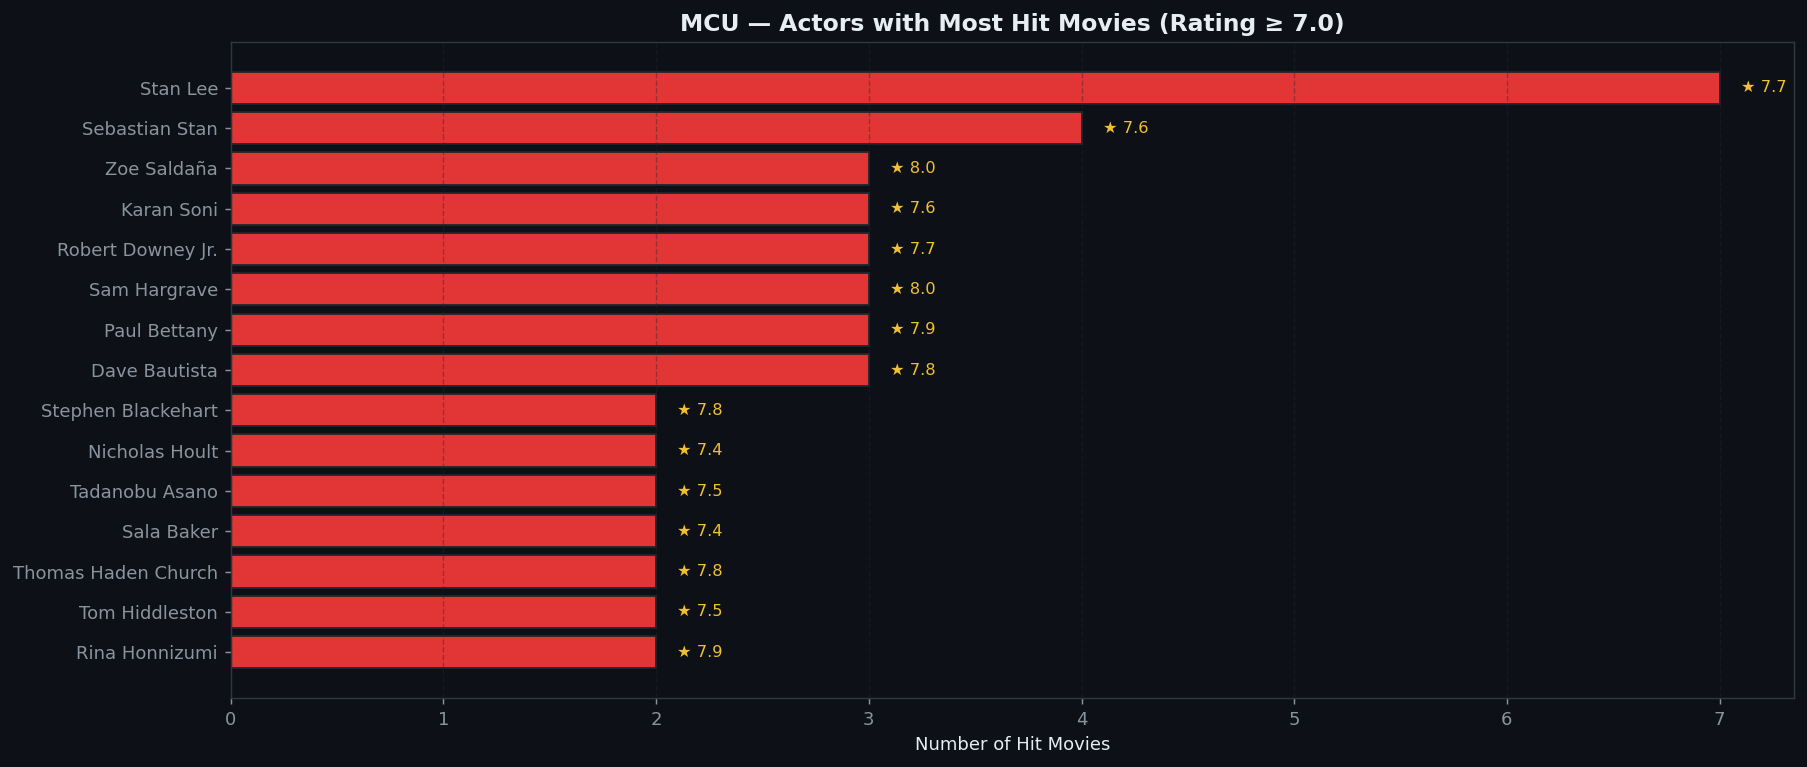

,actor,hit_movies,avg_rating,total_revenue
484,Stan Lee,7,7.714286,5.561429e+09
470,Sebastian Stan,4,7.600000,3.668930e+09
547,Zoe Saldaña,3,8.000000,4.435972e+09
281,Karan Soni,3,7.600000,1.620084e+09
442,Robert Downey Jr.,3,7.666667,3.145624e+09
455,Sam Hargrave,3,7.966667,4.440638e+09
401,Paul Bettany,3,7.866667,4.042993e+09
135,Dave Bautista,3,7.833333,2.482083e+09
485,Stephen Blackehart,2,7.800000,1.636533e+09
382,Nicholas Hoult,2,7.400000,8.372465e+08



=== DC TOP HIT ACTORS ===


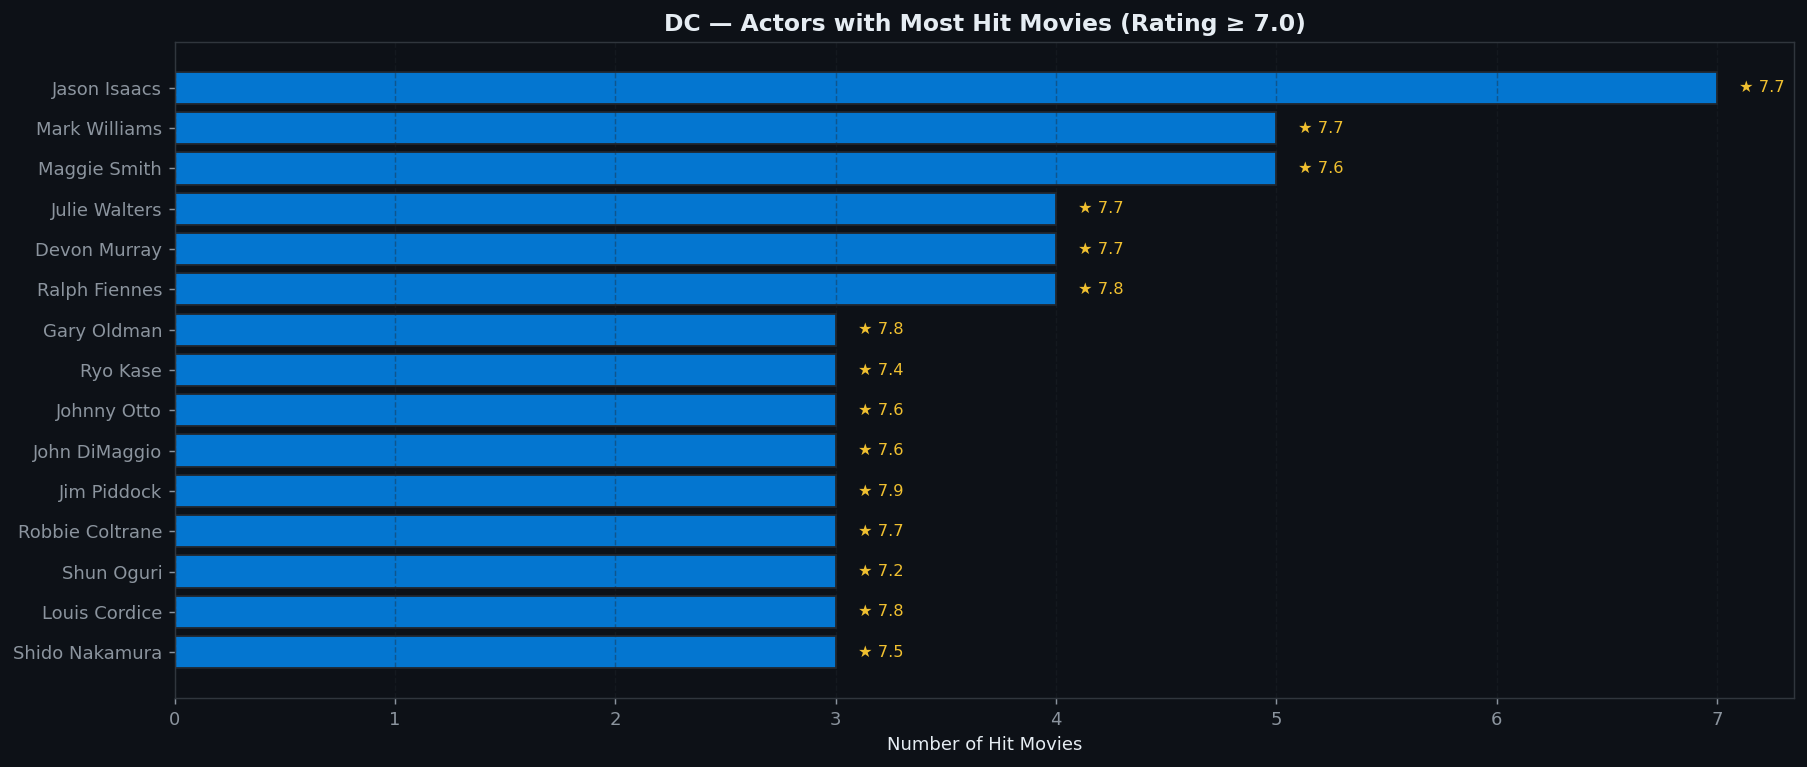

,actor,hit_movies,avg_rating,total_revenue
731,Jason Isaacs,7,7.728571,5.947228e+09
1117,Mark Williams,5,7.700000,5.006639e+09
1078,Maggie Smith,5,7.620000,4.092333e+09
873,Julie Walters,4,7.700000,4.110718e+09
402,Devon Murray,4,7.700000,4.052333e+09
1401,Ralph Fiennes,4,7.750000,4.129951e+09
525,Gary Oldman,3,7.766667,3.175645e+09
1505,Ryo Kase,3,7.400000,7.229443e+07
843,Johnny Otto,3,7.600000,1.587724e+09
810,John DiMaggio,3,7.566667,7.920020e+07


In [66]:
# "Hit" = movie with rating >= 7.0 AND revenue is known
def top_hit_actors(df_actors, universe, top_n=15, color=MCU_COLOR):
    hits = df_actors[(df_actors["rating"] >= 7.0) & df_actors["revenue"].notna()].copy()
    hit_counts = (hits.groupby("actor")
                      .agg(hit_movies=("title", "nunique"),
                           avg_rating =("rating",  "mean"),
                           total_revenue=("revenue","sum"))
                      .reset_index()
                      .query("hit_movies >= 2")
                      .sort_values("hit_movies", ascending=False)
                      .head(top_n))

    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.barh(hit_counts["actor"][::-1], hit_counts["hit_movies"][::-1], color=color, edgecolor="#21262d")
    
    for bar, avg_r in zip(bars, hit_counts["avg_rating"][::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f"★ {avg_r:.1f}", va="center", fontsize=9, color="#f0c030")
    
    ax.set_title(f"{universe} — Actors with Most Hit Movies (Rating ≥ 7.0)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Hit Movies")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
    return hit_counts

print("=== MCU TOP HIT ACTORS ===")
mcu_hits = top_hit_actors(df_mcu_actors, "MCU", color=MCU_COLOR)
display(mcu_hits.head(10))

print("\n=== DC TOP HIT ACTORS ===")
dc_hits = top_hit_actors(df_dc_actors, "DC", color=DC_COLOR)
display(dc_hits.head(10))

# Result interpretation: Actors with a high hit-movie count are consistently
# associated with commercially and critically successful productions. The star
# annotation (average rating) indicates whether volume of hits is accompanied
# by sustained quality — high count with high rating signals a genuinely
# reliable box-office and critical asset.

## Highest-Grossing Actors by Cumulative Box-Office Revenue

I aggregate cumulative box-office revenue per actor (across films with at least two appearances in the dataset) to identify the talent most strongly associated with commercial performance within each universe.

=== MCU BOX-OFFICE KINGS ===


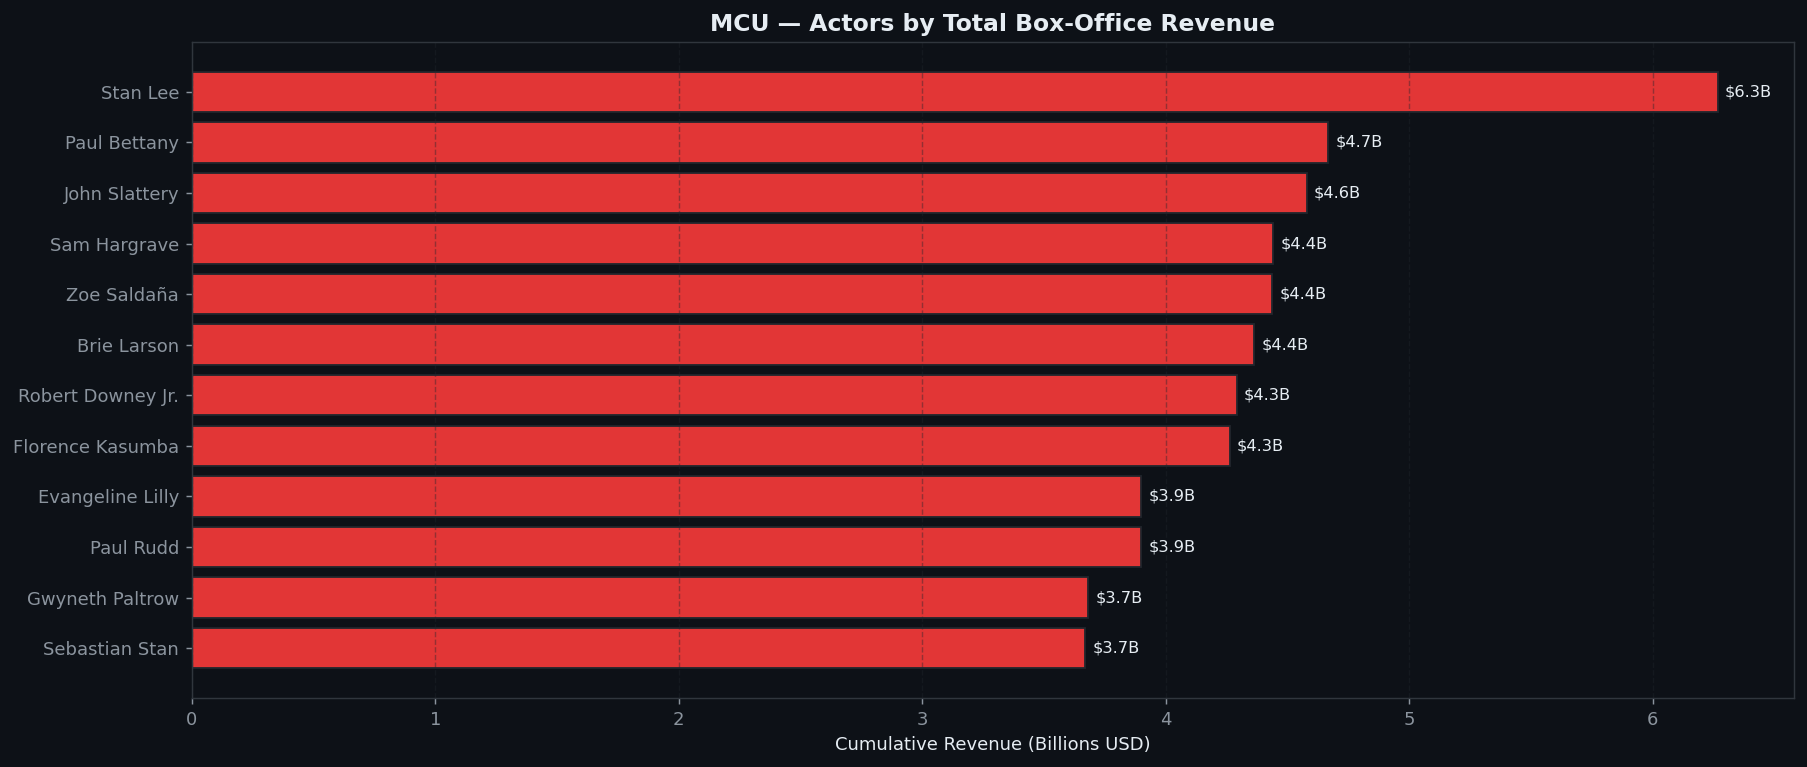

,actor,total_revenue,movies,revenue_B
1118,Stan Lee,6.266149e+09,9,6.266149
925,Paul Bettany,4.666926e+09,4,4.666926
595,John Slattery,4.578419e+09,3,4.578419
1042,Sam Hargrave,4.440638e+09,3,4.440638
1273,Zoe Saldaña,4.435972e+09,3,4.435972
178,Brie Larson,4.363099e+09,3,4.363099
1012,Robert Downey Jr.,4.291416e+09,5,4.291416
385,Florence Kasumba,4.261443e+09,3,4.261443
371,Evangeline Lilly,3.898184e+09,3,3.898184
931,Paul Rudd,3.898184e+09,3,3.898184



=== DC BOX-OFFICE KINGS ===


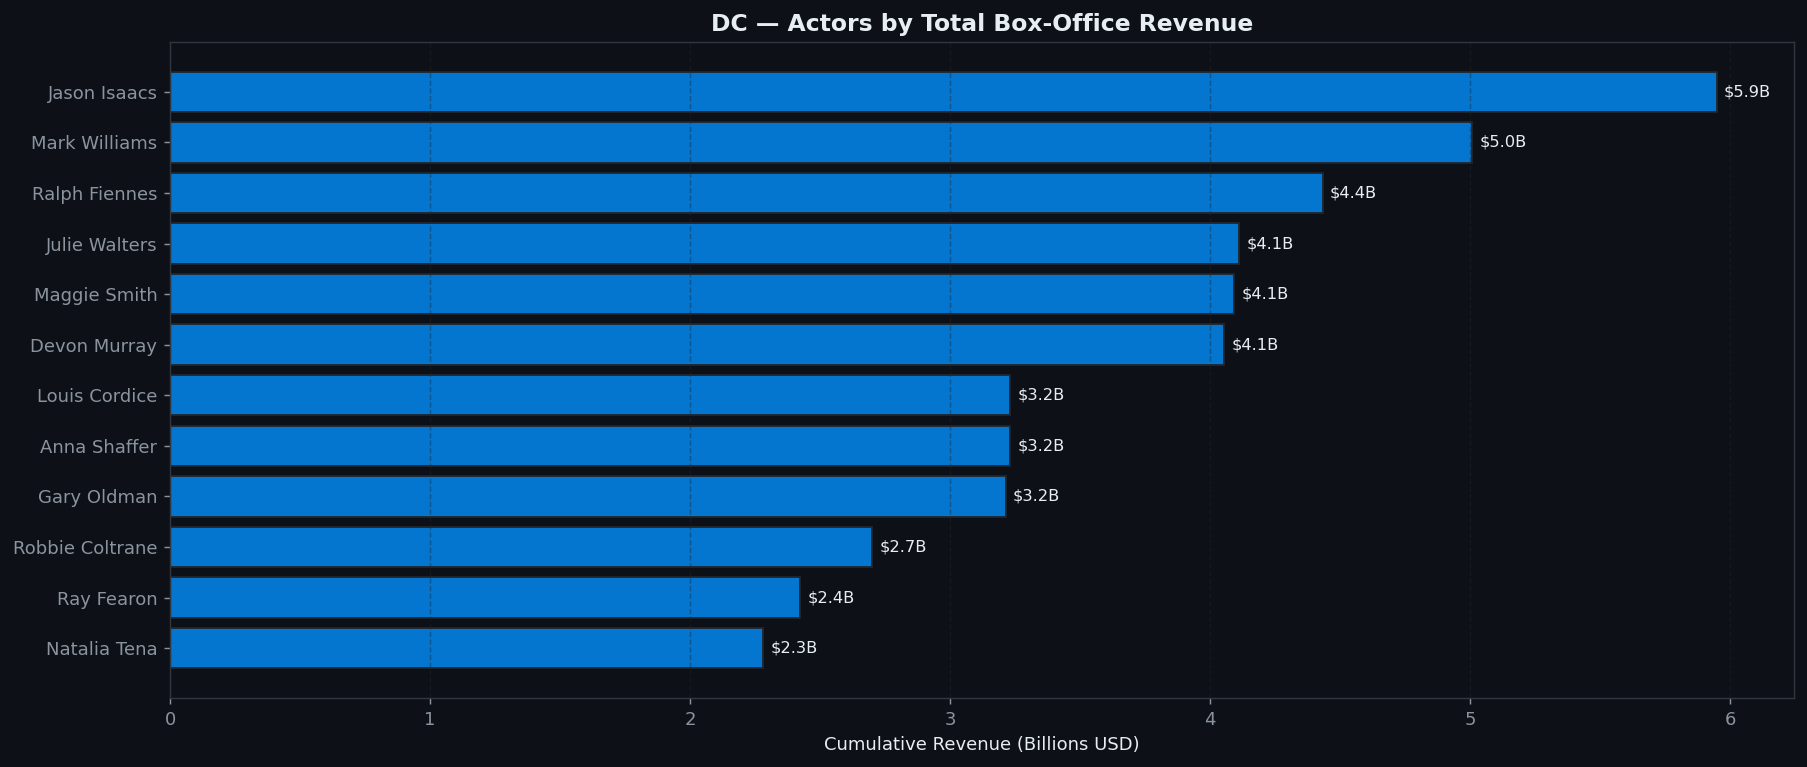

,actor,total_revenue,movies,revenue_B
2445,Jason Isaacs,5.947228e+09,7,5.947228
3736,Mark Williams,5.006639e+09,5,5.006639
4679,Ralph Fiennes,4.431921e+09,5,4.431921
2941,Julie Walters,4.110718e+09,4,4.110718
3602,Maggie Smith,4.092333e+09,5,4.092333
1373,Devon Murray,4.052333e+09,4,4.052333
3518,Louis Cordice,3.229776e+09,3,3.229776
311,Anna Shaffer,3.229776e+09,3,3.229776
1808,Gary Oldman,3.213856e+09,4,3.213856
4871,Robbie Coltrane,2.700598e+09,4,2.700598


In [67]:
def revenue_kings(df_actors, universe, top_n=12, color=MCU_COLOR):
    grp = (df_actors.dropna(subset=["revenue"])
                    .groupby("actor")
                    .agg(total_revenue=("revenue","sum"),
                         movies=("title","nunique"))
                    .reset_index()
                    .query("movies >= 2")
                    .sort_values("total_revenue", ascending=False)
                    .head(top_n))

    grp["revenue_B"] = grp["total_revenue"] / 1e9

    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.barh(grp["actor"][::-1], grp["revenue_B"][::-1], color=color, edgecolor="#21262d")
    ax.bar_label(bars, fmt=lambda x: f"${x:.1f}B", padding=4, color="#e6edf3", fontsize=9)
    ax.set_title(f"{universe} — Actors by Total Box-Office Revenue", fontsize=13, fontweight="bold")
    ax.set_xlabel("Cumulative Revenue (Billions USD)")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
    return grp

print("=== MCU BOX-OFFICE KINGS ===")
display(revenue_kings(df_mcu_actors, "MCU", color=MCU_COLOR))

print("\n=== DC BOX-OFFICE KINGS ===")
display(revenue_kings(df_dc_actors, "DC", color=DC_COLOR))

# Result interpretation: Cumulative revenue reflects an actor's aggregate
# commercial contribution to their universe. High totals indicate either
# long careers in the franchise or consistent presence in tent-pole releases.
# This metric does not control for number of films and should be read
# alongside hit-count data from Section 6.


## Best Director-Actor Collaborations

I evaluate recurring director-actor pairings (two or more shared films) using a composite score that weights critical reception at 60% and commercial performance at 40%. This formulation reflects the academic priority of quality-first evaluation while acknowledging revenue as a meaningful signal of audience reach.

=== MCU — DIRECTOR-ACTOR DREAM TEAMS ===


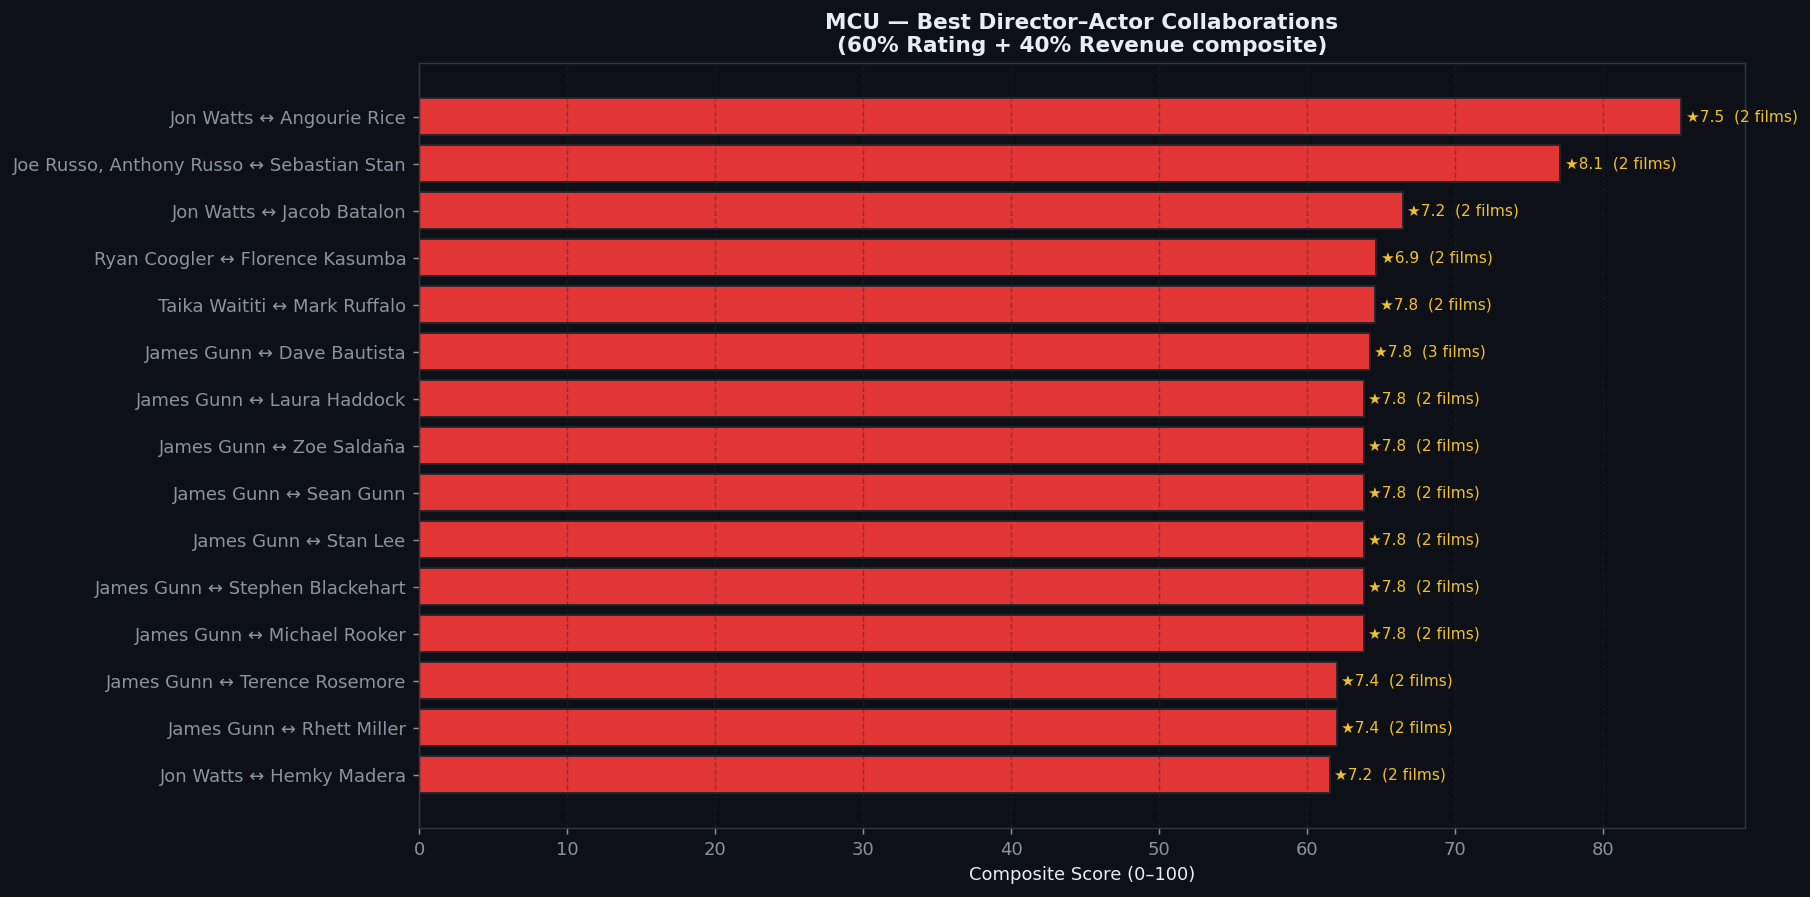

,label,collab_count,avg_rating,combo_score
1480,Jon Watts ↔ Angourie Rice,2,7.550000,85.300000
1367,"Joe Russo, Anthony Russo ↔ Sebastian Stan",2,8.050000,77.097105
1498,Jon Watts ↔ Jacob Batalon,2,7.150000,66.475720
2684,Ryan Coogler ↔ Florence Kasumba,2,6.950000,64.688595
2958,Taika Waititi ↔ Mark Ruffalo,2,7.800000,64.601662
1085,James Gunn ↔ Dave Bautista,3,7.833333,64.220119
1094,James Gunn ↔ Laura Haddock,2,7.800000,63.830831
1121,James Gunn ↔ Zoe Saldaña,2,7.800000,63.830831
1115,James Gunn ↔ Sean Gunn,2,7.800000,63.830831
1117,James Gunn ↔ Stan Lee,2,7.800000,63.830831



=== DC — DIRECTOR-ACTOR DREAM TEAMS ===


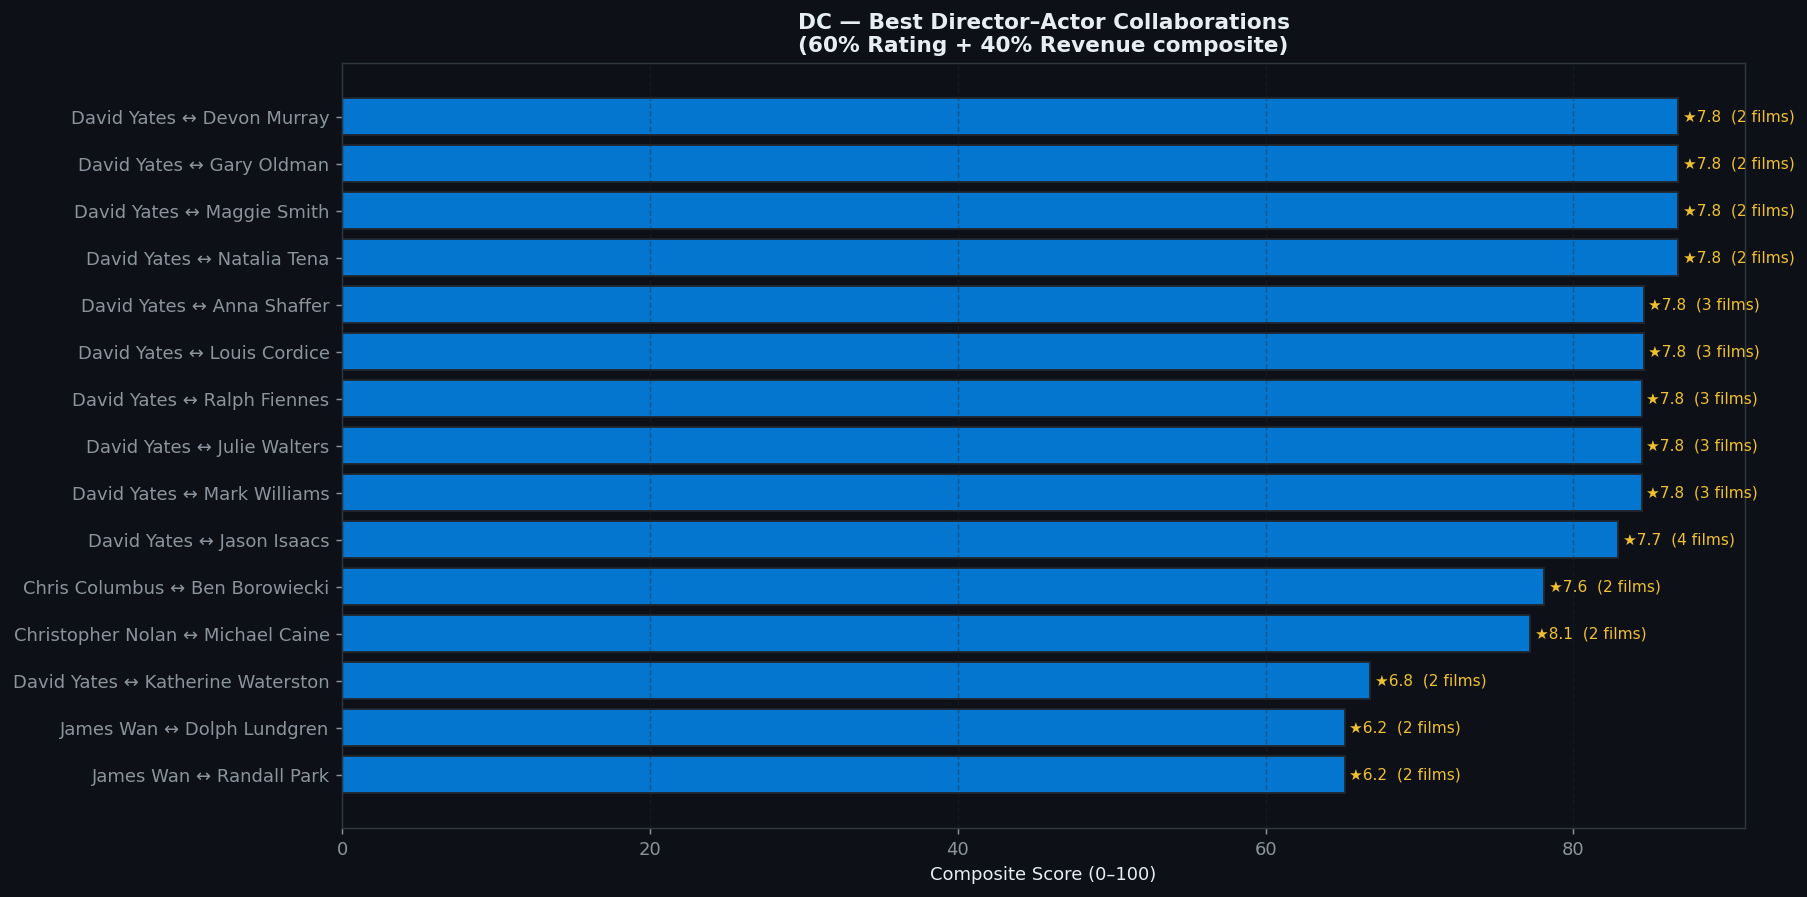

,label,collab_count,avg_rating,combo_score
3361,David Yates ↔ Devon Murray,2,7.800000,86.800000
3370,David Yates ↔ Gary Oldman,2,7.800000,86.800000
3403,David Yates ↔ Maggie Smith,2,7.800000,86.800000
3414,David Yates ↔ Natalia Tena,2,7.800000,86.800000
3345,David Yates ↔ Anna Shaffer,3,7.800000,84.579735
3399,David Yates ↔ Louis Cordice,3,7.800000,84.579735
3421,David Yates ↔ Ralph Fiennes,3,7.766667,84.429490
3395,David Yates ↔ Julie Walters,3,7.766667,84.429490
3406,David Yates ↔ Mark Williams,3,7.766667,84.429490
3386,David Yates ↔ Jason Isaacs,4,7.725000,82.915734


In [68]:
def director_actor_combos(df_actors, universe, top_n=15, color=MCU_COLOR):
    combo = (df_actors.dropna(subset=["rating"])
                      .groupby(["director","actor"])
                      .agg(collab_count=("title","nunique"),
                           avg_rating=("rating","mean"),
                           avg_revenue=("revenue","mean"))
                      .reset_index()
                      .query("collab_count >= 2"))

    # Composite score: 60% rating (normalised to 10) + 40% revenue rank
    combo["rating_score"]  = combo["avg_rating"] / 10
    rev_max = combo["avg_revenue"].max()
    combo["revenue_score"] = combo["avg_revenue"].fillna(0) / rev_max if rev_max > 0 else 0
    combo["combo_score"]   = (0.6 * combo["rating_score"] + 0.4 * combo["revenue_score"]) * 100
    combo = combo.sort_values("combo_score", ascending=False).head(top_n)

    combo["label"] = combo["director"] + " ↔ " + combo["actor"]

    fig, ax = plt.subplots(figsize=(14, 7))
    bars = ax.barh(combo["label"][::-1], combo["combo_score"][::-1], color=color, edgecolor="#21262d")
    for bar, rating, count in zip(bars, combo["avg_rating"][::-1], combo["collab_count"][::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f"★{rating:.1f}  ({int(count)} films)", va="center", fontsize=8.5, color="#f0c030")
    ax.set_title(f"{universe} — Best Director–Actor Collaborations\n(60% Rating + 40% Revenue composite)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Composite Score (0–100)")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
    return combo[["label","collab_count","avg_rating","combo_score"]]

print("=== MCU — DIRECTOR-ACTOR DREAM TEAMS ===")
display(director_actor_combos(df_mcu_actors, "MCU", color=MCU_COLOR))

print("\n=== DC — DIRECTOR-ACTOR DREAM TEAMS ===")
display(director_actor_combos(df_dc_actors, "DC", color=DC_COLOR))

# Result interpretation: The composite score (60% rating, 40% revenue)
# surfaces collaborations that excel on both critical and commercial dimensions.
# A high score with multiple shared films indicates a productive creative
# partnership that studios could consider a reliable quality signal.

## Director Leaderboard — Rating and ROI

I rank directors who have helmed at least two films within each universe, evaluating them separately by average IMDb rating and average return on investment. This dual-axis view distinguishes critical success from financial efficiency.

=== MCU DIRECTOR LEADERBOARD ===


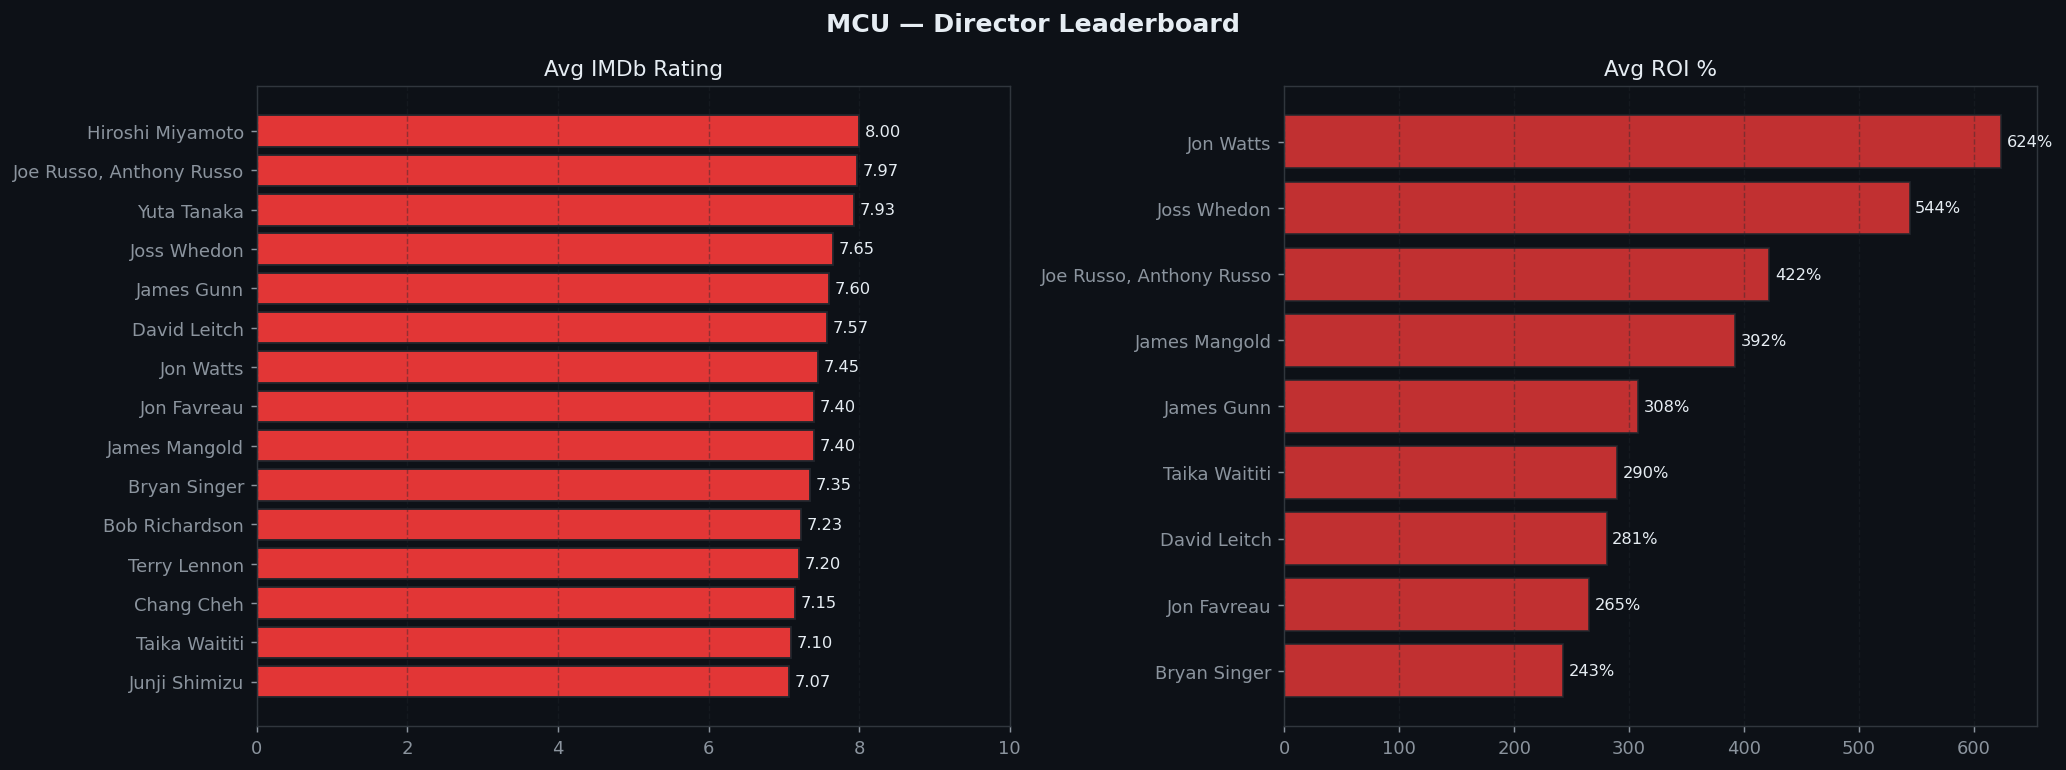

,director,movies,avg_rating,avg_roi,total_rev
0,Hiroshi Miyamoto,2,8.00,NaN,1.037801e+07
1,"Joe Russo, Anthony Russo",3,7.97,422.2,3.922228e+09
2,Yuta Tanaka,3,7.93,NaN,8.280000e+06
3,Joss Whedon,2,7.65,544.2,2.924219e+09
4,James Gunn,4,7.60,308.2,2.482083e+09
5,David Leitch,3,7.57,280.6,8.372465e+08
6,Jon Watts,4,7.45,624.1,3.935549e+09
7,Jon Favreau,2,7.40,265.0,1.209108e+09
8,James Mangold,2,7.40,392.2,1.034462e+09
9,Bryan Singer,4,7.35,242.6,1.996032e+09



=== DC DIRECTOR LEADERBOARD ===


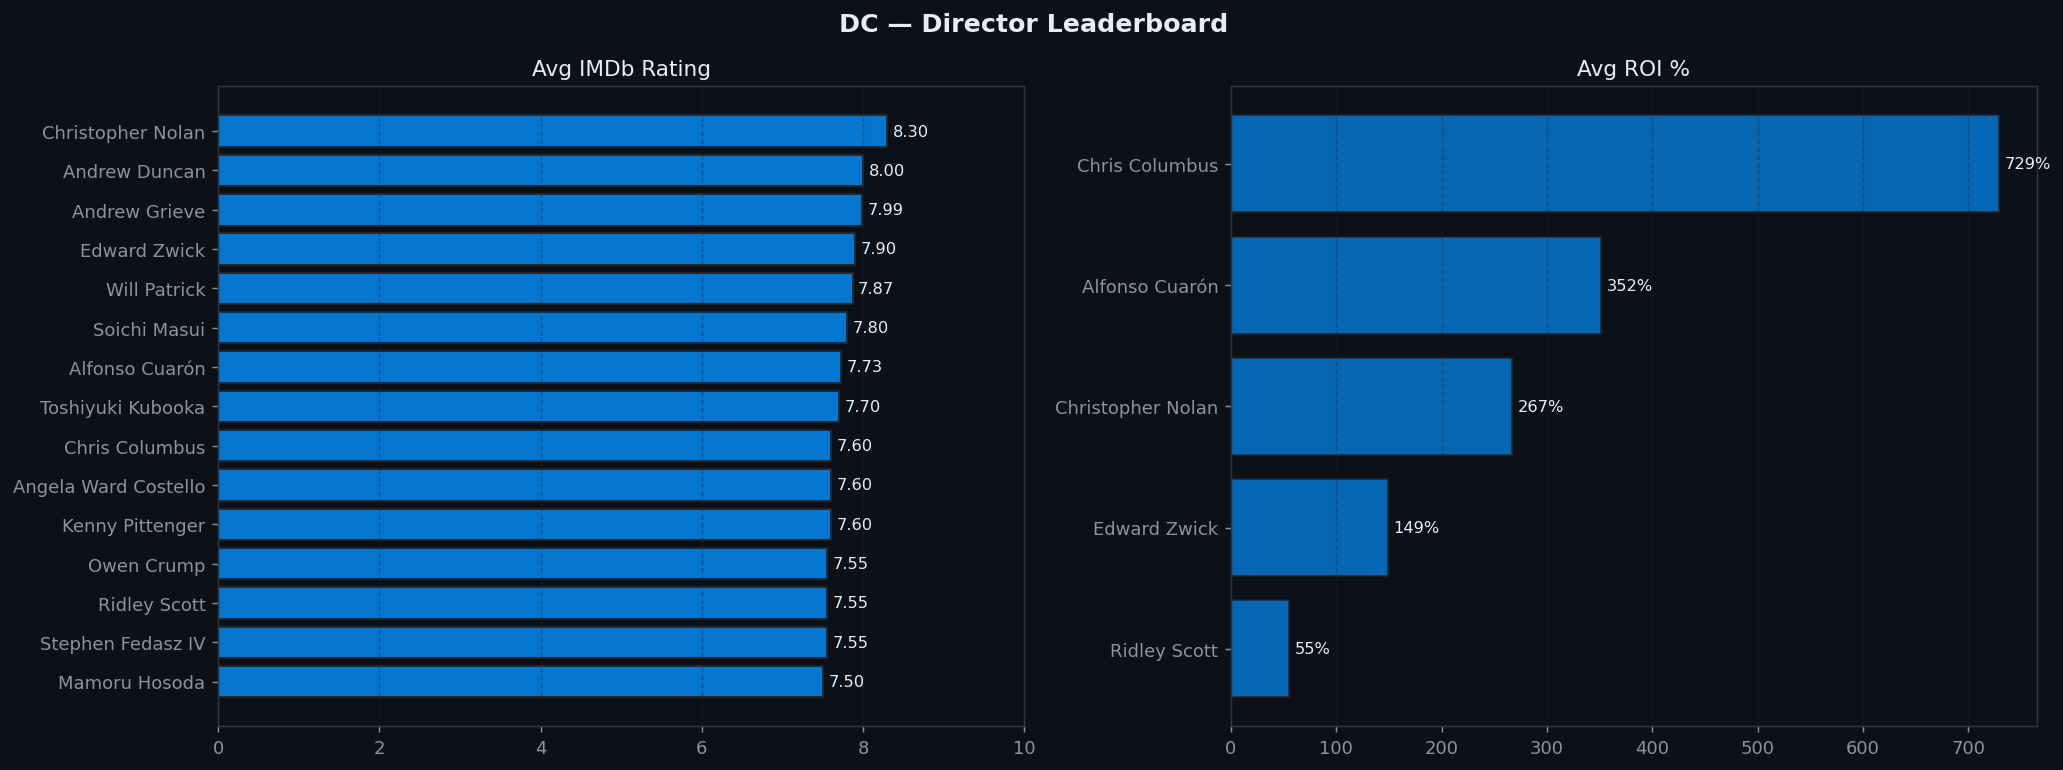

,director,movies,avg_rating,avg_roi,total_rev
0,Christopher Nolan,7,8.30,266.8,4.322966e+09
1,Andrew Duncan,3,8.00,NaN,NaN
2,Andrew Grieve,8,7.99,NaN,NaN
3,Edward Zwick,2,7.90,149.0,6.285204e+08
4,Will Patrick,3,7.87,NaN,NaN
5,Soichi Masui,3,7.80,NaN,2.050242e+06
6,Alfonso Cuarón,3,7.73,351.7,1.522997e+09
7,Toshiyuki Kubooka,2,7.70,NaN,2.552055e+06
8,Chris Columbus,2,7.60,728.9,1.853164e+09
9,Angela Ward Costello,3,7.60,NaN,NaN


In [69]:
def director_leaderboard(table_name, universe, color=MCU_COLOR):
    df = conn.sql(f"""
        SELECT director,
               COUNT(*)              AS movies,
               ROUND(AVG(rating),2)  AS avg_rating,
               ROUND(AVG(roi_pct),1) AS avg_roi,
               SUM(revenue)          AS total_rev
        FROM {table_name}
        WHERE director IS NOT NULL
        GROUP BY director
        HAVING COUNT(*) >= 2
        ORDER BY avg_rating DESC
        LIMIT 15
    """).df()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"{universe} — Director Leaderboard", fontsize=14, fontweight="bold")

    # Avg rating
    b1 = axes[0].barh(df["director"][::-1], df["avg_rating"][::-1], color=color, edgecolor="#21262d")
    axes[0].set_title("Avg IMDb Rating")
    axes[0].set_xlim(0, 10)
    axes[0].bar_label(b1, fmt="%.2f", padding=3, color="#e6edf3", fontsize=9)

    # Avg ROI
    df2 = df.dropna(subset=["avg_roi"]).sort_values("avg_roi", ascending=False).head(15)
    b2 = axes[1].barh(df2["director"][::-1], df2["avg_roi"][::-1], color=color, edgecolor="#21262d", alpha=0.85)
    axes[1].set_title("Avg ROI %")
    axes[1].bar_label(b2, fmt="%.0f%%", padding=3, color="#e6edf3", fontsize=9)

    for ax in axes:
        ax.grid(axis="x", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()
    return df

print("=== MCU DIRECTOR LEADERBOARD ===")
display(director_leaderboard("mcu_movies", "MCU", MCU_COLOR))

print("\n=== DC DIRECTOR LEADERBOARD ===")
display(director_leaderboard("dc_movies", "DC", DC_COLOR))

# Result interpretation: The rating panel identifies directors who consistently
# deliver critically well-received work; the ROI panel identifies those whose
# films generate strong financial returns relative to budget. Directors who
# rank highly on both axes represent the strongest combined creative and
# commercial case within each universe.


## Superhero Franchise Reach Index

**Reach** measures how broadly a superhero's film franchise penetrated global audiences.  
**Formula:** `Reach Score = (Total Revenue / 1M) x log10(Total Vote Count + 1) x Avg Rating`

I apply this formula to reward franchises that achieved *both* commercial scale and critical acceptance, rather than either dimension alone. The logarithmic vote term compresses outlier audience sizes while preserving meaningful distinctions.

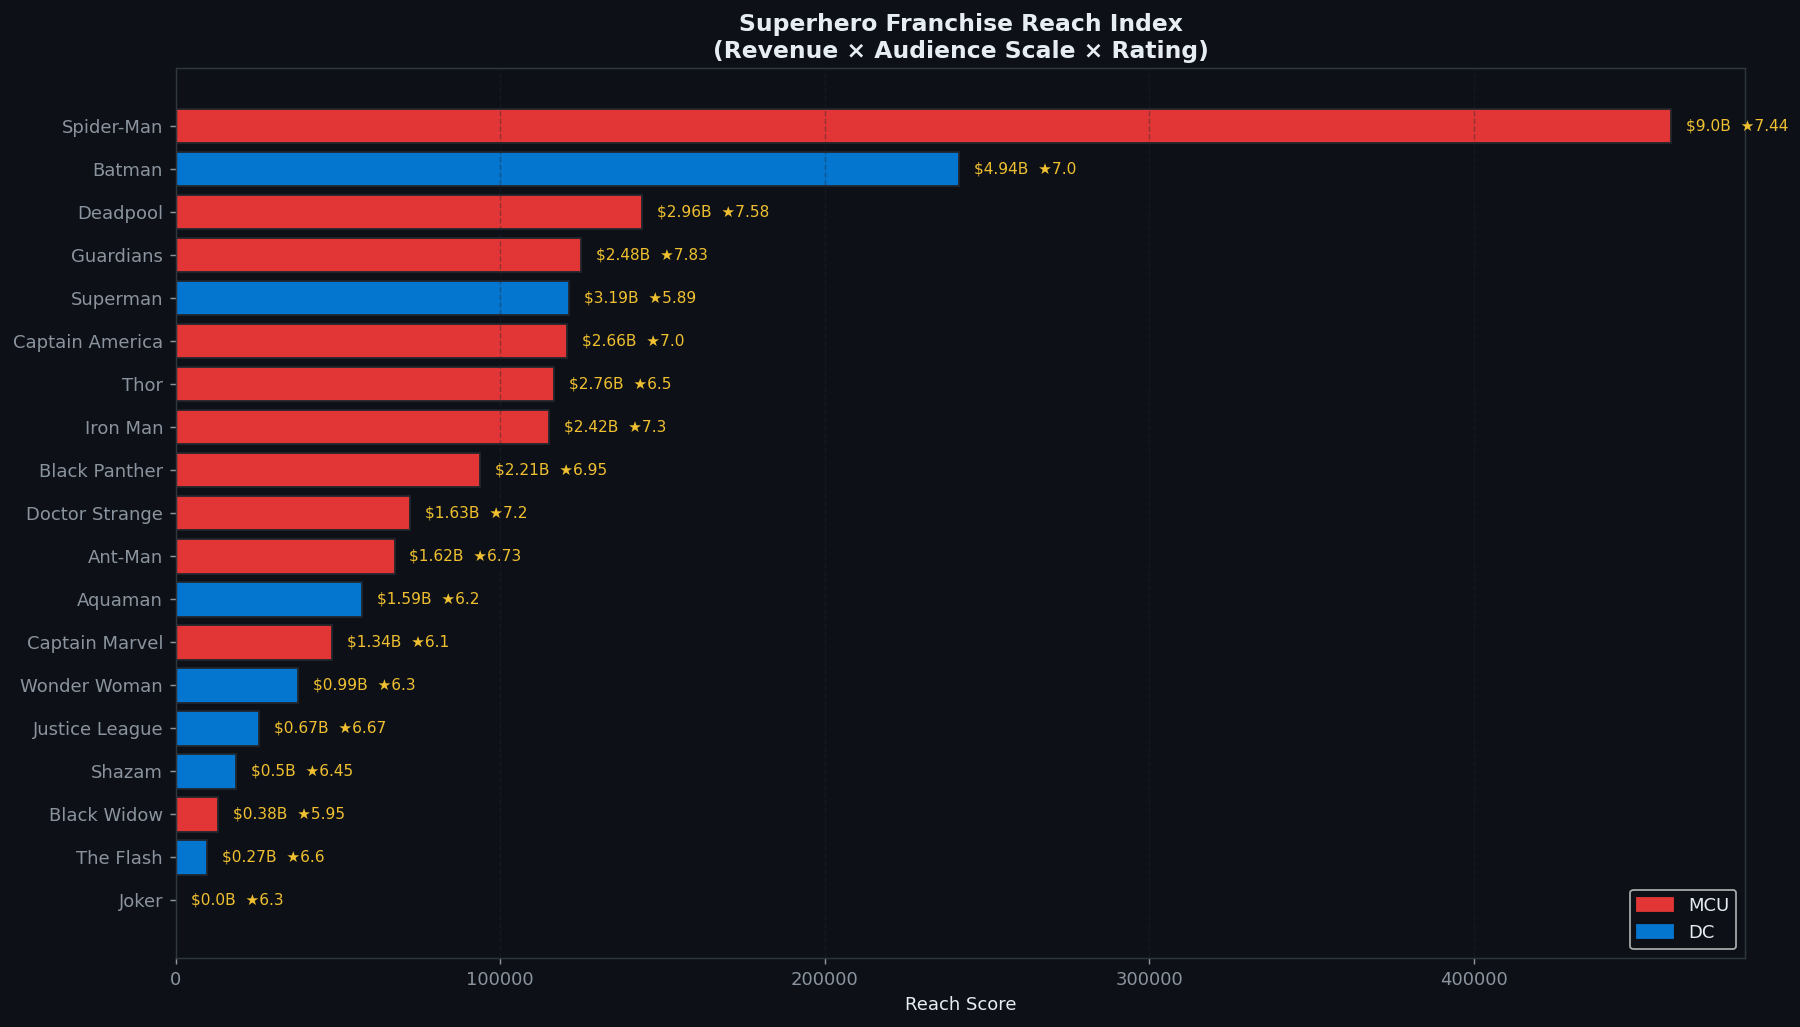

,superhero,universe,films,total_revenue_B,avg_rating,total_votes_M,reach_score
4,Spider-Man,MCU,10,9.00,7.44,7.55,460694.0
12,Batman,DC,16,4.94,7.00,9.50,241306.0
10,Deadpool,MCU,4,2.96,7.58,2.56,143602.0
7,Guardians,MCU,3,2.48,7.83,2.66,124911.0
11,Superman,DC,10,3.19,5.89,2.85,121189.0
2,Captain America,MCU,4,2.66,7.00,3.04,120508.0
1,Thor,MCU,9,2.76,6.50,3.14,116441.0
0,Iron Man,MCU,3,2.42,7.30,3.12,114950.0
3,Black Panther,MCU,2,2.21,6.95,1.28,93742.0
5,Doctor Strange,MCU,2,1.63,7.20,1.42,72300.0


In [70]:
# Superhero → canonical film title keywords
SUPERHERO_MAP = {
    "Iron Man":          ["Iron Man"],
    "Thor":              ["Thor"],
    "Captain America":   ["Captain America"],
    "Black Panther":     ["Black Panther"],
    "Spider-Man":        ["Spider-Man", "Spider Man"],
    "Doctor Strange":    ["Doctor Strange"],
    "Ant-Man":           ["Ant-Man", "Ant Man"],
    "Guardians":         ["Guardians of the Galaxy"],
    "Captain Marvel":    ["Captain Marvel", "The Marvels"],
    "Black Widow":       ["Black Widow"],
    "Scarlet Witch":     ["Scarlet Witch", "WandaVision"],
    "Deadpool":          ["Deadpool"],
    "Superman":          ["Superman", "Man of Steel"],
    "Batman":            ["Batman", "Dark Knight"],
    "Wonder Woman":      ["Wonder Woman"],
    "Aquaman":           ["Aquaman"],
    "The Flash":         ["The Flash"],
    "Joker":             ["Joker"],
    "Shazam":            ["Shazam"],
    "Justice League":    ["Justice League"],
}

df_vfx = conn.sql("SELECT title, rating, revenue, vote_count FROM vfx_movies").df()

records = []
for hero, keywords in SUPERHERO_MAP.items():
    mask = pd.Series([False]*len(df_vfx))
    for kw in keywords:
        mask |= df_vfx["title"].str.contains(kw, case=False, na=False)
    sub = df_vfx[mask].dropna(subset=["revenue","rating"])
    if sub.empty:
        continue
    total_rev   = sub["revenue"].sum()
    avg_rating  = sub["rating"].mean()
    total_votes = sub["vote_count"].dropna().sum()
    n_films     = len(sub)
    reach = (total_rev / 1e6) * np.log10(total_votes + 1) * avg_rating
    records.append({
        "superhero":    hero,
        "films":        n_films,
        "total_revenue_B": round(total_rev / 1e9, 2),
        "avg_rating":   round(avg_rating, 2),
        "total_votes_M": round(total_votes / 1e6, 2),
        "reach_score":  round(reach, 0),
        "universe":     "MCU" if any(kw in " ".join(MCU_TITLES) for kw in keywords) else "DC"
    })

df_reach = pd.DataFrame(records).sort_values("reach_score", ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
colors_map = [MCU_COLOR if u == "MCU" else DC_COLOR for u in df_reach["universe"]]
bars = ax.barh(df_reach["superhero"][::-1], df_reach["reach_score"][::-1],
               color=colors_map[::-1], edgecolor="#21262d")
for bar, rev, rating in zip(bars, df_reach["total_revenue_B"][::-1], df_reach["avg_rating"][::-1]):
    ax.text(bar.get_width() + df_reach["reach_score"].max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f"${rev}B  ★{rating}", va="center", fontsize=8.5, color="#f0c030")

mcu_patch = mpatches.Patch(color=MCU_COLOR, label="MCU")
dc_patch  = mpatches.Patch(color=DC_COLOR,  label="DC")
ax.legend(handles=[mcu_patch, dc_patch], loc="lower right")
ax.set_title("Superhero Franchise Reach Index\n(Revenue × Audience Scale × Rating)", fontsize=13, fontweight="bold")
ax.set_xlabel("Reach Score")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

display(df_reach[["superhero","universe","films","total_revenue_B","avg_rating","total_votes_M","reach_score"]])
# Result interpretation: A high Reach Score indicates the franchise attracted
# both mass ticket buyers and engaged audiences (as measured by vote counts),
# while maintaining strong ratings. Franchises that score high on reach but
# lower on power (Section 11) may have peaked commercially without
# sustaining critical quality across instalments.


## Superhero Power Index — Cultural Strength Score

**Power** measures sustained excellence across multiple instalments.  
**Formula:** `Power Index = avg_rating x log10(avg_votes + 1) x (1 + 0.1 x films)`

Unlike the Reach Index, which rewards total accumulated impact, the Power Index rewards *consistency*: a hero who maintains high ratings and strong audience engagement across many films scores higher than one who peaked in a single blockbuster. I consider this the most defensible comparative metric for franchise cultural dominance.

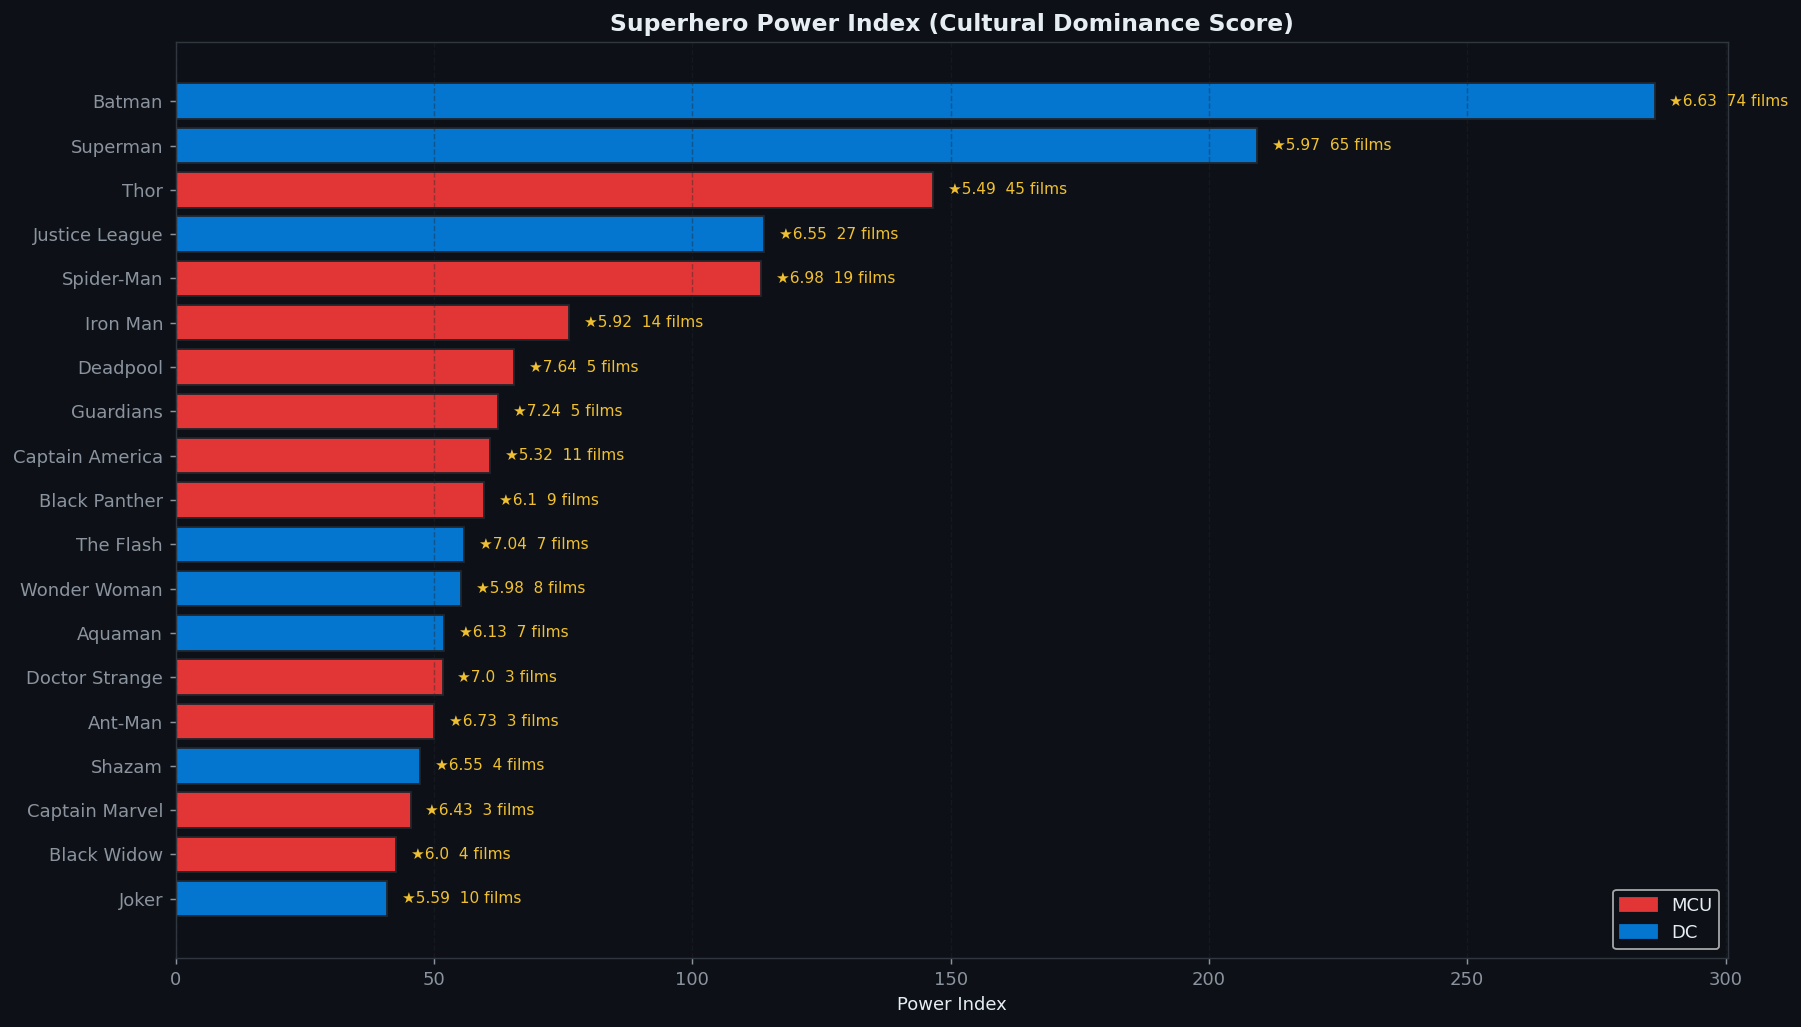

,superhero,universe,films,avg_rating,avg_votes_K,power_index
12,Batman,DC,74,6.63,137.1,286.26
11,Superman,DC,65,5.97,47.6,209.36
1,Thor,MCU,45,5.49,71.2,146.61
18,Justice League,DC,27,6.55,50.5,113.95
4,Spider-Man,MCU,19,6.98,397.8,113.33
0,Iron Man,MCU,14,5.92,226.3,76.10
10,Deadpool,MCU,5,7.64,514.2,65.45
7,Guardians,MCU,5,7.24,553.3,62.37
2,Captain America,MCU,11,5.32,278.7,60.81
3,Black Panther,MCU,9,6.10,142.2,59.72


In [71]:
power_records = []
for hero, keywords in SUPERHERO_MAP.items():
    mask = pd.Series([False]*len(df_vfx))
    for kw in keywords:
        mask |= df_vfx["title"].str.contains(kw, case=False, na=False)
    sub = df_vfx[mask].dropna(subset=["rating"])
    if sub.empty:
        continue
    avg_rating  = sub["rating"].mean()
    avg_votes   = sub["vote_count"].dropna().mean() if sub["vote_count"].dropna().any() else 0
    n_films     = len(sub)
    power = avg_rating * np.log10(avg_votes + 1) * (1 + 0.1 * n_films)
    power_records.append({
        "superhero": hero,
        "films":     n_films,
        "avg_rating": round(avg_rating, 2),
        "avg_votes_K": round(avg_votes / 1e3, 1),
        "power_index": round(power, 2),
        "universe":  "MCU" if any(kw in " ".join(MCU_TITLES) for kw in keywords) else "DC"
    })

df_power = pd.DataFrame(power_records).sort_values("power_index", ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
colors_pow = [MCU_COLOR if u=="MCU" else DC_COLOR for u in df_power["universe"]]
bars = ax.barh(df_power["superhero"][::-1], df_power["power_index"][::-1],
               color=colors_pow[::-1], edgecolor="#21262d")
for bar, rating, n in zip(bars, df_power["avg_rating"][::-1], df_power["films"][::-1]):
    ax.text(bar.get_width() + df_power["power_index"].max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f"★{rating}  {int(n)} films", va="center", fontsize=8.5, color="#f0c030")

ax.legend(handles=[mcu_patch, dc_patch], loc="lower right")
ax.set_title("Superhero Power Index (Cultural Dominance Score)", fontsize=13, fontweight="bold")
ax.set_xlabel("Power Index")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

display(df_power[["superhero","universe","films","avg_rating","avg_votes_K","power_index"]])
# Result interpretation: The Power Index rewards sustained performance across
# multiple films. A high power score with a large film count confirms that
# the franchise maintained audience and critical engagement over time — the
# most reliable indicator of long-term cultural franchise strength.


## MCU vs DC — Release Timeline and Rating Trends

I examine year-by-year trajectories for both universes between 2000 and 2025, tracking average IMDb rating in the upper panel and total annual box-office revenue in the lower panel. This longitudinal view reveals how each franchise evolved in critical reception and commercial momentum over time.

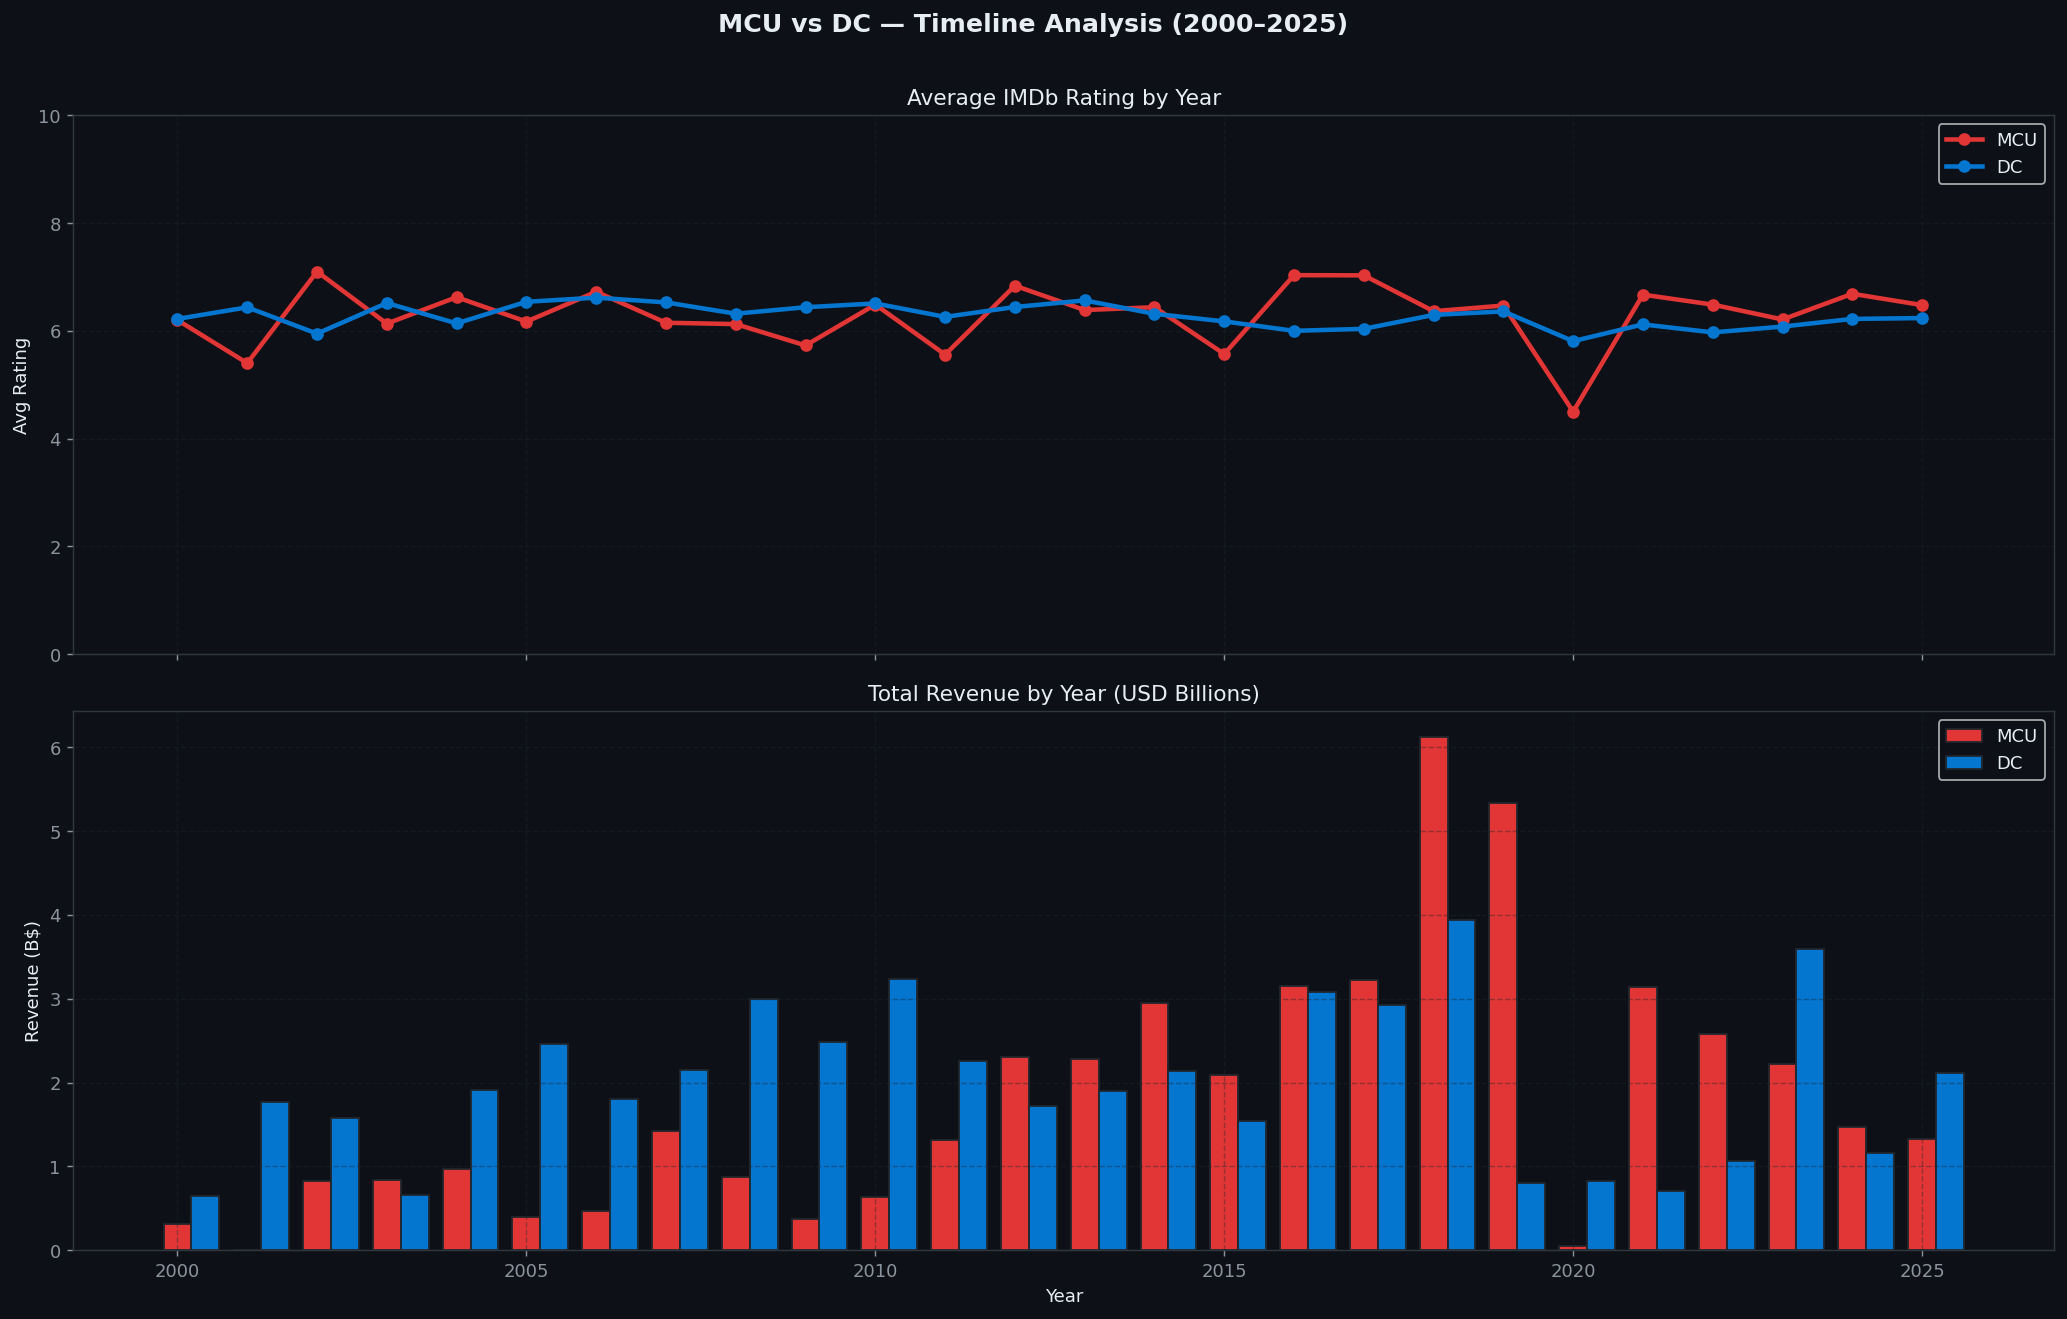

In [72]:
df_uni = conn.sql("""
    SELECT title, release_year, rating, revenue, universe
    FROM universe_movies
    WHERE release_year IS NOT NULL AND release_year BETWEEN 2000 AND 2025
""").df()

timeline = df_uni.groupby(["release_year","universe"]).agg(
    avg_rating=("rating","mean"),
    total_rev=("revenue","sum"),
    count=("title","count")
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for uni, color in [("MCU", MCU_COLOR), ("DC", DC_COLOR)]:
    sub = timeline[timeline["universe"] == uni]
    axes[0].plot(sub["release_year"], sub["avg_rating"], marker="o", color=color, label=uni, linewidth=2.5)
    axes[1].bar(sub["release_year"] + (0 if uni=="MCU" else 0.4),
                sub["total_rev"]/1e9, width=0.4, color=color, label=uni, edgecolor="#21262d")

axes[0].set_title("Average IMDb Rating by Year", fontsize=12)
axes[0].set_ylabel("Avg Rating")
axes[0].legend()
axes[0].set_ylim(0, 10)
axes[0].grid(linestyle="--", alpha=0.4)

axes[1].set_title("Total Revenue by Year (USD Billions)", fontsize=12)
axes[1].set_ylabel("Revenue (B$)")
axes[1].legend()
axes[1].grid(linestyle="--", alpha=0.4)
axes[1].set_xlabel("Year")

fig.suptitle("MCU vs DC — Timeline Analysis (2000–2025)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
# Result interpretation: Upward rating trends indicate improving creative
# quality over time, while revenue spikes correspond to high-profile
# crossover or climactic events within each universe. Diverging trajectories
# between the two panels suggest a franchise may be commercially growing
# while critical reception declines, or vice versa — a meaningful signal
# for strategic franchise planning.


## Actors Appearing in Both MCU and DC

I compute the intersection of MCU and DC actor sets to identify talent who have worked across both universes. For each crossover actor, I record the number of films and average rating within each universe to assess whether cross-universe participation correlates with consistent quality.

In [73]:
mcu_actor_set = set(df_mcu_actors["actor"].dropna().unique())
dc_actor_set  = set(df_dc_actors["actor"].dropna().unique())
crossover     = mcu_actor_set & dc_actor_set

crossover_df = []
for actor in sorted(crossover):
    mcu_r = df_mcu_actors[df_mcu_actors["actor"]==actor]["rating"].mean()
    dc_r  = df_dc_actors[df_dc_actors["actor"]==actor]["rating"].mean()
    mcu_n = df_mcu_actors[df_mcu_actors["actor"]==actor]["title"].nunique()
    dc_n  = df_dc_actors[df_dc_actors["actor"]==actor]["title"].nunique()
    crossover_df.append({"actor":actor,"mcu_films":mcu_n,"dc_films":dc_n,
                          "mcu_avg_rating":round(mcu_r,2),"dc_avg_rating":round(dc_r,2)})

df_cross = (pd.DataFrame(crossover_df)
              .sort_values(["mcu_films","dc_films"], ascending=False)
              .head(20))

print(f"Found {len(crossover)} actors appearing in both MCU & DC films")
display(df_cross)
# Result interpretation: Actors appearing in both universes are relatively
# rare. Comparing their average rating in each universe reveals whether
# their association with high-quality productions is universe-specific or
# a consistent personal characteristic. A consistent high average across
# both suggests genuine talent rather than franchise-driven uplift.


Found 579 actors appearing in both MCU & DC films


,actor,mcu_films,dc_films,mcu_avg_rating,dc_avg_rating
158,Fred Tatasciore,20,45,6.17,6.30
529,Trevor Devall,14,10,6.16,6.18
156,Frank Welker,12,67,7.00,6.50
121,Dee Bradley Baker,11,29,5.78,6.37
478,Stan Lee,11,2,7.26,6.55
59,Brian Drummond,9,5,6.50,7.52
399,Peter Cullen,9,2,6.92,7.05
502,Tara Strong,7,46,5.96,6.51
269,Kevin Michael Richardson,7,44,6.30,6.37
430,Roger Craig Smith,7,9,5.59,6.13


## Neo4j Graph Export (MCU and DC)

I export three CSV files structured for import into a Neo4j graph database: movie nodes, director nodes, and directed-by relationship edges. This graph-ready export enables future network analysis of director-film relationships within the combined universe dataset.

In [74]:
import os
OUTPUT_DIR = "."

# Movie nodes
conn.sql(f"""
    COPY (
        SELECT DISTINCT id AS movieId, title, release_year, rating,
                        vote_average, budget, revenue, roi_pct,
                        runtime, genres, original_language, universe
        FROM universe_movies WHERE title IS NOT NULL
    )
    TO '{OUTPUT_DIR}/neo4j_universe_movies.csv' (HEADER, DELIMITER ',')
""")

# Director nodes
conn.sql(f"""
    COPY (
        SELECT DISTINCT director AS name FROM universe_movies
        WHERE director IS NOT NULL AND TRIM(director) != ''
    )
    TO '{OUTPUT_DIR}/neo4j_universe_directors.csv' (HEADER, DELIMITER ',')
""")

# DIRECTED relationships
conn.sql(f"""
    COPY (
        SELECT DISTINCT id AS movieId, director AS directorName
        FROM universe_movies
        WHERE director IS NOT NULL AND TRIM(director) != ''
    )
    TO '{OUTPUT_DIR}/neo4j_universe_directed_by.csv' (HEADER, DELIMITER ',')
""")

# Actor nodes
conn.sql(f"""
    COPY (
        SELECT DISTINCT actor AS name, universe
        FROM (
            SELECT TRIM(UNNEST(STRING_SPLIT(cast_list, ','))) AS actor, universe
            FROM universe_movies
            WHERE cast_list IS NOT NULL AND TRIM(cast_list) != ''
        )
        WHERE actor != ''
    )
    TO '{OUTPUT_DIR}/neo4j_universe_actors.csv' (HEADER, DELIMITER ',')
""")

# ACTED_IN relationships (actor → movie, with revenue for easy lookup)
conn.sql(f"""
    COPY (
        SELECT DISTINCT
            TRIM(UNNEST(STRING_SPLIT(cast_list, ','))) AS actorName,
            id AS movieId,
            title,
            revenue,
            rating,
            universe
        FROM universe_movies
        WHERE cast_list IS NOT NULL AND TRIM(cast_list) != ''
    )
    TO '{OUTPUT_DIR}/neo4j_universe_acted_in.csv' (HEADER, DELIMITER ',')
""")

# DIRECTED_BY with actor bridge — director ↔ actor shared films
conn.sql(f"""
    COPY (
        SELECT DISTINCT
            director AS directorName,
            TRIM(UNNEST(STRING_SPLIT(cast_list, ','))) AS actorName,
            id AS movieId,
            title,
            rating,
            revenue,
            universe
        FROM universe_movies
        WHERE cast_list IS NOT NULL AND TRIM(cast_list) != ''
          AND director IS NOT NULL AND TRIM(director) != ''
    )
    TO '{OUTPUT_DIR}/neo4j_universe_director_actor.csv' (HEADER, DELIMITER ',')
""")

print("Neo4j CSVs exported:")
for f in [
    "neo4j_universe_movies.csv",
    "neo4j_universe_directors.csv",
    "neo4j_universe_directed_by.csv",
    "neo4j_universe_actors.csv",
    "neo4j_universe_acted_in.csv",
    "neo4j_universe_director_actor.csv"
]:
    size = os.path.getsize(f) if os.path.exists(f) else 0
    print(f"  {f}  ({size:,} bytes)")

# Result interpretation: Six CSVs cover the complete graph structure —
# movie and person nodes plus all three relationship types (directed,
# acted-in, director-actor bridge). With these loaded into Neo4j you can
# traverse actor-revenue paths, director-actor collaboration networks,
# and cross-universe talent comparisons in a single Cypher query.


Neo4j CSVs exported:
  neo4j_universe_movies.csv  (245,792 bytes)
  neo4j_universe_directors.csv  (27,297 bytes)
  neo4j_universe_directed_by.csv  (64,743 bytes)
  neo4j_universe_actors.csv  (590,349 bytes)
  neo4j_universe_acted_in.csv  (2,685,943 bytes)
  neo4j_universe_director_actor.csv  (3,487,311 bytes)


## 15. Neo4j Cypher Queries — MCU and DC Universe Graph

I execute four Cypher queries against the populated Neo4j graph to extract director-level insights that would require more verbose SQL with the tabular DuckDB model. These queries cover prolific recent directors, ROI-ranked directors, genre co-occurrence patterns, and cross-universe performance comparison.

In [75]:
from neo4j import GraphDatabase
import pandas as pd

URI      = "neo4j://127.0.0.1:7687"
USERNAME = "neo4j"
PASSWORD = "nidhichaubey"   

driver = GraphDatabase.driver(URI, auth=(USERNAME, PASSWORD))

def run_query(cypher, label="Result"):
    with driver.session() as session:
        result = session.run(cypher)
        df = pd.DataFrame([r.data() for r in result])
    print(f"\n=== {label} ===")
    display(df)
    return df


In [76]:
run_query("CALL db.labels()", "Labels")


=== Labels ===


,label
0,Movie
1,Actor
2,Director


,label
0,Movie
1,Actor
2,Director


In [77]:
# ── Cypher 1: Most prolific VFX directors since 2010 ──────────────────────
q1 = """
MATCH (d:Director)-[:DIRECTED]->(m:Movie)
WHERE m.year > 2010
RETURN d.name AS director, COUNT(m) AS recent_films
ORDER BY recent_films DESC LIMIT 15
"""
df_q1 = run_query(q1, "Q1 — Prolific VFX Directors since 2010")
# Result interpretation: Directors with the most films since 2010 have been
# the most active creative forces in the modern VFX era. High counts may
# reflect studio confidence and franchise alignment.



=== Q1 — Prolific VFX Directors since 2010 ===


,director,recent_films
0,Sam Liu,13
1,Ethan Spaulding,10
2,Shinsuke Sato,9
3,Matt Peters,9
4,Jay Oliva,8
5,Rick Morales,8
6,David Gemmill,7
7,Jeff Wamester,7
8,Gianluca Leuzzi,6
9,"Tony Cervone, Spike Brandt",6


In [78]:
# ── Cypher 2: Highest avg ROI directors (min 2 films) ─────────────────────
q2 = """
MATCH (d:Director)-[:DIRECTED]->(m:Movie)
WHERE m.roi_pct IS NOT NULL
WITH d.name AS director, AVG(m.roi_pct) AS avg_roi, COUNT(m) AS film_count
WHERE film_count >= 2
RETURN director, ROUND(avg_roi,1) AS avg_roi_pct, film_count
ORDER BY avg_roi_pct DESC LIMIT 15
"""
df_q2 = run_query(q2, "Q2 — Highest Avg ROI Directors")
# Result interpretation: High average ROI with a minimum film threshold of
# two confirms this is not a single-film anomaly. These directors consistently
# deliver financial returns, making them commercially low-risk choices.



=== Q2 — Highest Avg ROI Directors ===


,director,avg_roi_pct,film_count
0,Gianluca Leuzzi,2508.8,5
1,Robert Clouse,1345.7,2
2,James Fargo,1008.8,2
3,Chris Columbus,728.9,2
4,Sydney Pollack,636.0,2
5,Jon Watts,624.1,3
6,Joss Whedon,544.2,2
7,Catherine Hardwicke,538.1,2
8,Hal Needham,454.3,3
9,"Joe Russo, Anthony Russo",422.2,3


In [79]:
# ── Cypher 3: Directors sharing genre space (collaboration affinity) ────────
q3 = """
MATCH (a:Director)-[:DIRECTED]->(m1:Movie),
      (b:Director)-[:DIRECTED]->(m2:Movie)
WHERE id(a) < id(b)
  AND m1.genres IS NOT NULL
  AND m1.genres = m2.genres
WITH a, b, COUNT(*) AS shared_genre_combos
WHERE shared_genre_combos > 3
RETURN a.name AS director_a, b.name AS director_b, shared_genre_combos
ORDER BY shared_genre_combos DESC LIMIT 10
"""
df_q3 = run_query(q3, "Q3 — Directors in Same Genre Space")
# Result interpretation: Directors who repeatedly work within the same genre
# space share creative territory. High shared-genre counts may indicate
# competitive overlap or complementary stylistic influences worth studying.


Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. id is deprecated. It is replaced by elementId or consider using an application-generated id.', position=<SummaryInputPosition line=4, column=7, offset=94>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 94, 'line': 4, 'column': 7}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\nMATCH (a:Director)-[:DIRECTED]->(m1:Movie),\n      (b:Director)-[:DIRECTED]->(m2:Movie)\nWHERE id(a) < id(b)\n  AND m1.genres IS NOT NULL\n  AND m1.genres = m2.genres\nWITH a, b, COUNT(*) AS shared_genre_combos\nWHERE shared_genre_combos > 3\nRETURN a.name AS director_a, b.name AS director_b, shared_genre_combos\


=== Q3 — Directors in Same Genre Space ===


,director_a,director_b,shared_genre_combos
0,Friz Freleng,Chuck Jones,10207
1,Friz Freleng,Robert McKimson,9529
2,Chuck Jones,Robert McKimson,9188
3,Robert Clampett,Friz Freleng,1700
4,Robert Clampett,Chuck Jones,1646
5,Robert Clampett,Robert McKimson,1509
6,Friz Freleng,Arthur Davis,1452
7,Chuck Jones,Arthur Davis,1397
8,Robert McKimson,Arthur Davis,1310
9,Tex Avery,Friz Freleng,1156


In [80]:
# ── Cypher 4: MCU vs DC avg rating via universe tag ───────────────────────
q4 = """
MATCH (m:Movie)
WHERE m.universe IS NOT NULL
RETURN m.universe AS universe,
       COUNT(m)             AS total_films,
       ROUND(AVG(m.rating), 2) AS avg_rating,
       ROUND(AVG(m.roi_pct),1) AS avg_roi
ORDER BY avg_rating DESC
"""
df_q4 = run_query(q4, "Q4 — MCU vs DC Performance in Graph")
# Result interpretation: Graph-derived universe performance metrics cross-
# validate the DuckDB findings in Section 4. Consistent results across both
# engines confirm data integrity; discrepancies would indicate tagging or
# deduplication issues requiring investigation.



=== Q4 — MCU vs DC Performance in Graph ===


,universe,total_films,avg_rating,avg_roi
0,DC,2405,6.37,249.0
1,MCU,365,6.19,284.5


In [ ]:
driver.close()
print("All Neo4j queries complete.")


All Neo4j queries complete.
